# Cyber Threat Landscape Analysis

## 1. Dataset Selection

### Dataset Name
University of Maryland Cyber Events Database

### Domain
Cybersecurity

### Dataset Source
University of Maryland - Cyber Events Database

### Project Objective
The objective of this project is to analyze historical cyber events and identify
patterns in cyber attacks based on event type, threat actors, industries,
motives, geographic distribution, and changes over time.

### Why This Dataset?
The dataset was selected because it contains real-world cyber event information
and provides multiple categorical, temporal, and descriptive attributes that
are suitable for exploratory data analysis.

The dataset allows us to investigate:
- What types of cyber events occur most frequently?
- Which threat actors are most commonly associated with cyber events?
- Which industries are targeted most frequently?
- What are the common motives behind cyber events?
- How have cyber events changed over time?
- Which industries are associated with different types of cyber events?
- Which countries and regions are most affected?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cyber_file = r"C:\Users\HP\Downloads\EDAPRPOJECT\UMD Cyber Attacks Dataset.xlsx"

state_file = r"C:\Users\HP\Downloads\EDAPRPOJECT\US State Names.xlsx"

breach_file = r"C:\Users\HP\Downloads\EDAPRPOJECT\USDHH Data Breaches.xlsx"

In [3]:
df = pd.read_excel(cyber_file)

In [4]:
df.head()

,slug,event_date,year,month,actor,actor_type,organization,industry_code,industry,motive,event_type,event_subtype,description,source_url,country,actor_country
0,1f72c2eb8ab303e4,2014-01-01,2014,1,Undetermined,Criminal,Barry University,61,Educational Services,Undetermined,Exploitive,Exploitation of End Hosts,Barry University notifies patients of its Foot...,https://www.beckershospitalreview.com/healthca...,United States of America,Undetermined
1,ecac8b3e60a2f72f,2014-01-01,2014,1,Undetermined,Criminal,Record Assist LLC,54,"Professional, Scientific, and Technical Services",Undetermined,Exploitive,Exploitation of Application Server,Record Assist LLC notifies of an unauthorized ...,https://privacyrights.org/data-breaches/record...,United States of America,Undetermined
2,3bbe0695e2d019f3,2014-01-01,2014,1,Syrian Electronic Army,Hacktivist,Skype's Social Media,54,"Professional, Scientific, and Technical Services",Protest,Disruptive,Message Manipulation,The Syrian Electronic Army hacks Skype's Twitt...,http://thenextweb.com/microsoft/2014/01/01/sky...,United States of America,Syrian Arab Republic
3,6100014f6ca84b3d,2014-01-02,2014,1,Undetermined,Criminal,Snapchat,51,Information,Undetermined,Exploitive,Exploitation of Application Server,Greyhat hackers publish the partial phone numb...,http://arstechnica.com/security/2014/01/greyha...,United States of America,Undetermined
4,3a94b8cf6dde1f66,2014-01-03,2014,1,DERP Trolling,Undetermined,Battle.net,51,Information,Undetermined,Disruptive,External Denial of Service,"The servers for Steam, Origin, Battle.net, and...",http://arstechnica.com/gaming/2014/01/multiple...,United States of America,Undetermined


In [5]:
df.shape

(13841, 16)

In [6]:
df.columns.tolist()

['slug',
 'event_date',
 'year',
 'month',
 'actor',
 'actor_type',
 'organization',
 'industry_code',
 'industry',
 'motive',
 'event_type',
 'event_subtype',
 'description',
 'source_url',
 'country',
 'actor_country']

### Column Description

| Column | Description |
|---|---|
| slug | Unique identifier for the cyber event |
| event_date | Date on which the cyber event occurred |
| year | Year of the cyber event |
| month | Month of the cyber event |
| actor | Identified threat actor or group |
| actor_type | Type/category of threat actor |
| organization | Organization affected by the event |
| industry_code | Industry classification code |
| industry | Industry of the affected organization |
| motive | Reported or classified motive of the event |
| event_type | Broad classification of the cyber event |
| event_subtype | Specific type/subcategory of the cyber event |
| description | Description of the cyber event |
| source_url | Source/reference URL for the event |
| country | Country associated with the affected organization/event |
| actor_country | Country associated with the threat actor |

### Target Variable

This project is exploratory rather than predictive, so the dataset does not
contain a dedicated machine-learning target variable.

The primary analytical outcome used in this project is `event_type`,
which is used to examine the distribution and characteristics of different
types of cyber events.

Other important analytical dimensions include `actor_type`, `industry`,
`motive`, `event_subtype`, `country`, and `year`.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13841 entries, 0 to 13840
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   slug           13841 non-null  object
 1   event_date     13841 non-null  object
 2   year           13841 non-null  int64 
 3   month          13841 non-null  int64 
 4   actor          13841 non-null  object
 5   actor_type     13841 non-null  object
 6   organization   13841 non-null  object
 7   industry_code  13841 non-null  int64 
 8   industry       13841 non-null  object
 9   motive         13841 non-null  object
 10  event_type     13841 non-null  object
 11  event_subtype  13821 non-null  object
 12  description    13839 non-null  object
 13  source_url     13837 non-null  object
 14  country        13841 non-null  object
 15  actor_country  13836 non-null  object
dtypes: int64(3), object(13)
memory usage: 1.7+ MB


In [8]:
structure_summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Non_Null_Count": df.notnull().sum().values,
    "Missing_Count": df.isnull().sum().values,
    "Unique_Values": df.nunique().values
})

structure_summary

,Column,Data_Type,Non_Null_Count,Missing_Count,Unique_Values
0,slug,object,13841,0,13841
1,event_date,object,13841,0,3280
2,year,int64,13841,0,11
3,month,int64,13841,0,12
4,actor,object,13841,0,1186
5,actor_type,object,13841,0,7
6,organization,object,13841,0,12642
7,industry_code,int64,13841,0,25
8,industry,object,13841,0,23
9,motive,object,13841,0,9


In [9]:
null_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

null_summary = null_summary.sort_values(
    by="Missing_Percentage",
    ascending=False
)

null_summary

,Missing_Count,Missing_Percentage
event_subtype,20,0.144498
actor_country,5,0.036125
source_url,4,0.028900
description,2,0.014450
slug,0,0.000000
event_date,0,0.000000
year,0,0.000000
month,0,0.000000
actor,0,0.000000
actor_type,0,0.000000


In [10]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", 
      round((duplicate_count / len(df)) * 100, 2), "%")

Duplicate rows: 0
Duplicate percentage: 0.0 %


In [11]:
[id_col for id_col in df.columns 
 if "id" in id_col.lower() or "slug" in id_col.lower()]

['slug']

In [12]:
df["slug"].duplicated().sum()

np.int64(0)

In [13]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

categorical_columns

Index(['slug', 'event_date', 'actor', 'actor_type', 'organization', 'industry',
       'motive', 'event_type', 'event_subtype', 'description', 'source_url',
       'country', 'actor_country'],
      dtype='object')

In [14]:
for col in categorical_columns:
    print("\n" + "="*60)
    print("COLUMN:", col)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(10))


COLUMN: slug
Unique values: 13841
slug
1f72c2eb8ab303e4    1
2f9d521fd8ceac4a    1
edff1a7b469255ec    1
7dfbd787f73a6d7b    1
fdb4953f263ff2b5    1
9f6694c92f6eeee5    1
b9ed883b1a63751a    1
fcaeccf8d8949d6f    1
198736c4e66abe32    1
5fdf5e2aff0031f5    1
Name: count, dtype: int64

COLUMN: event_date
Unique values: 3280
event_date
2017-06-27    78
2022-04-22    67
2017-05-12    64
2016-01-21    41
2020-09-25    38
2022-01-14    35
2016-03-29    33
2020-10-28    31
2023-01-06    28
2020-01-27    27
Name: count, dtype: int64

COLUMN: actor
Unique values: 1186
actor
Undetermined                                                                7904
cl0p                                                                         301
Anonymous                                                                    280
NoName057(16)                                                                269
Vice Society                                                                 162
LockBit 3.0          

In [15]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

numeric_columns

Index(['year', 'month', 'industry_code'], dtype='object')

In [16]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
year,13841.0,2019.833394,2.852742,2014.0,2018.0,2020.0,2022.0,2024.0
month,13841.0,6.419767,3.475130,1.0,3.0,7.0,9.0,12.0
industry_code,13841.0,63.245286,18.909945,11.0,52.0,61.0,81.0,99.0


In [17]:
[col for col in df.columns 
 if "date" in col.lower() or "time" in col.lower() or "year" in col.lower()]

['event_date', 'year']

In [18]:
df["event_date"] = pd.to_datetime(
    df["event_date"],
    errors="coerce"
)

In [19]:
print("Minimum date:", df["event_date"].min())
print("Maximum date:", df["event_date"].max())

Minimum date: 2014-01-01 00:00:00
Maximum date: 2024-08-25 00:00:00


In [20]:
df["event_date"].isnull().sum()

np.int64(0)

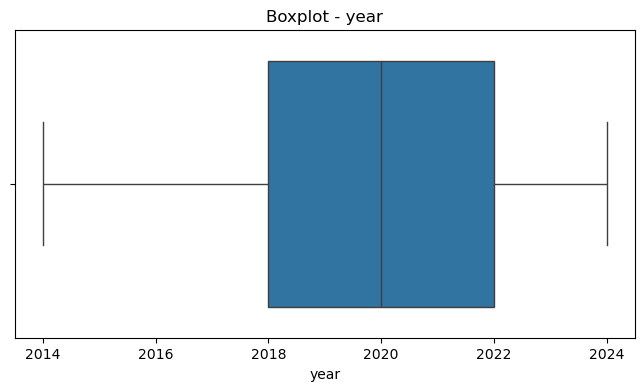

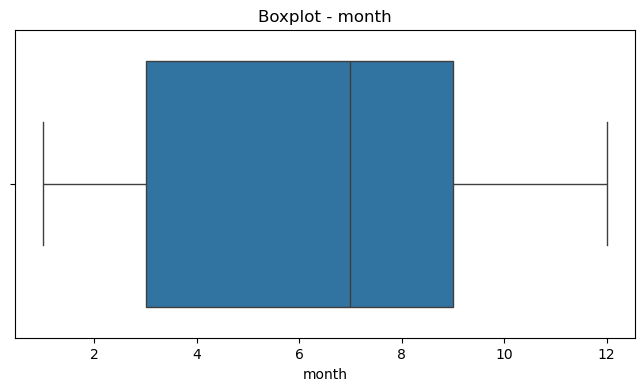

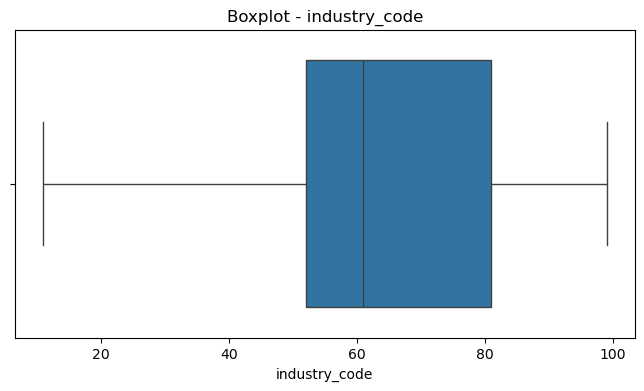

In [21]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

In [22]:
df["event_type"].value_counts(normalize=True) * 100

event_type
Exploitive      49.750741
Disruptive      31.218843
Mixed           17.773282
Undetermined     1.257135
Name: proportion, dtype: float64

In [23]:
df["actor_type"].value_counts(normalize=True) * 100

actor_type
Criminal        76.027744
Hacktivist      13.655083
Nation-State     5.707680
Undetermined     2.904414
Hobbyist         1.365508
Terrorist        0.216747
Hacktvist        0.122823
Name: proportion, dtype: float64

In [24]:
df["industry"].value_counts(normalize=True).head(15) * 100

industry
Public Administration                                                       19.745683
Health Care and Social Assistance                                           13.720107
Information                                                                 11.234737
Finance and Insurance                                                        9.775305
Educational Services                                                         9.645257
Professional, Scientific, and Technical Services                             8.445922
Manufacturing                                                                4.840691
Retail Trade                                                                 3.540207
Transportation and Warehousing                                               3.366809
Arts, Entertainment, and Recreation                                          3.164511
Other Services (except Public Administration)                                2.983888
Accommodation and Food Services              

In [26]:
df.columns = df.columns.str.lower()

In [27]:
df.columns.tolist()

['slug',
 'event_date',
 'year',
 'month',
 'actor',
 'actor_type',
 'organization',
 'industry_code',
 'industry',
 'motive',
 'event_type',
 'event_subtype',
 'description',
 'source_url',
 'country',
 'actor_country']

## 3. DATA CLEANING & PREPARATION

In [28]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    by="missing_percentage",
    ascending=False
)

missing_summary

,missing_count,missing_percentage
event_subtype,20,0.14
actor_country,5,0.04
source_url,4,0.03
description,2,0.01
slug,0,0.00
event_date,0,0.00
year,0,0.00
month,0,0.00
actor,0,0.00
actor_type,0,0.00


In [29]:
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percentage
event_subtype,20,0.14
actor_country,5,0.04
source_url,4,0.03
description,2,0.01


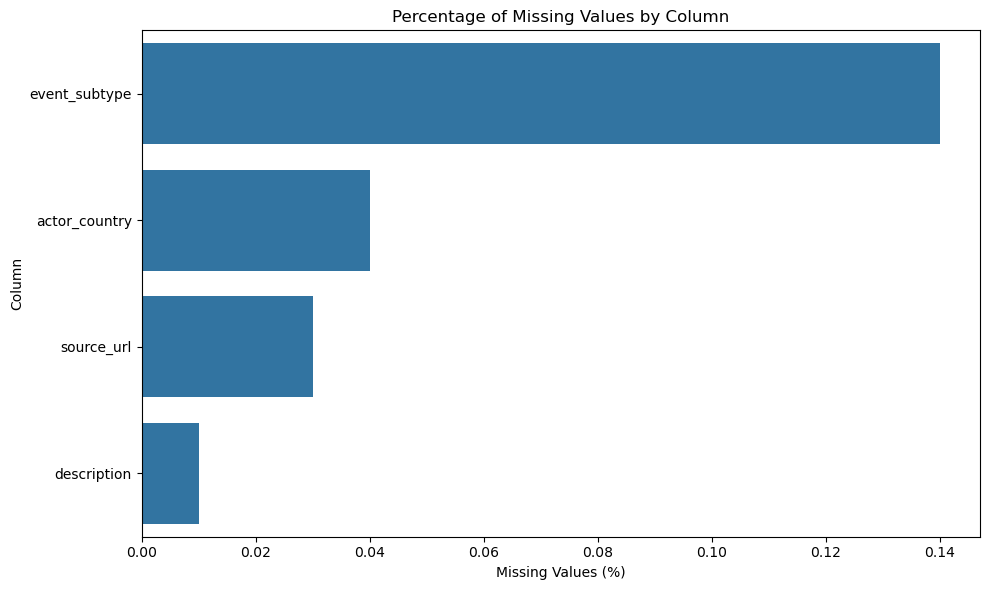

In [30]:
missing_plot = missing_summary[
    missing_summary["missing_count"] > 0
]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_plot["missing_percentage"],
    y=missing_plot.index
)

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")

plt.tight_layout()
plt.show()

### Missing Value Treatment

Missing values were first identified by calculating both the number and
percentage of missing observations in each column.

The treatment of missing values will depend on the meaning of each variable.
Categorical fields will not automatically be replaced with statistical
values such as mean or median. Where appropriate, missing categorical
information will be represented as "Unknown" or "Not Reported".

Important identifier or date fields will be investigated separately before
any values are modified.

In [32]:
duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)
print(
    "Duplicate percentage:",
    round(duplicate_count / len(df) * 100, 2),
    "%"
)

Duplicate records: 0
Duplicate percentage: 0.0 %


In [33]:
df[df.duplicated(keep=False)].head(20)

,slug,event_date,year,month,actor,actor_type,organization,industry_code,industry,motive,event_type,event_subtype,description,source_url,country,actor_country


In [34]:
df = df.drop_duplicates().reset_index(drop=True)

In [35]:
print("Duplicates after cleaning:", df.duplicated().sum())

Duplicates after cleaning: 0


### Duplicate Treatment

Complete duplicate records were identified using all columns.

If duplicate records were found, they were removed because they represent
repeated observations of the same record rather than independent cyber
events.

If no complete duplicates are identified, no records will be removed.

In [36]:
print("Total records:", len(df))
print("Unique slugs:", df["slug"].nunique())
print("Duplicate slugs:", df["slug"].duplicated().sum())

Total records: 13841
Unique slugs: 13841
Duplicate slugs: 0


In [37]:
df["event_date"] = pd.to_datetime(
    df["event_date"],
    errors="coerce"
)

In [38]:
print("Minimum date:", df["event_date"].min())
print("Maximum date:", df["event_date"].max())
print("Invalid dates:", df["event_date"].isna().sum())

Minimum date: 2014-01-01 00:00:00
Maximum date: 2024-08-25 00:00:00
Invalid dates: 0


In [39]:
for col in ["actor_type", "event_type", "motive"]:
    print("\n", "=" * 50)
    print(col)
    print(df[col].value_counts(dropna=False))


actor_type
actor_type
Criminal        10523
Hacktivist       1890
Nation-State      790
Undetermined      402
Hobbyist          189
Terrorist          30
Hacktvist          17
Name: count, dtype: int64

event_type
event_type
Exploitive      6886
Disruptive      4321
Mixed           2460
Undetermined     174
Name: count, dtype: int64

motive
motive
Financial                      7881
Undetermined                   3104
Protest                        1662
Political-Espionage             670
Sabotage                        337
Personal Attack                  93
Industrial-Espionage             92
Protest,Financial                 1
Protest;Political-Espionage       1
Name: count, dtype: int64


In [40]:
df["actor_type"] = df["actor_type"].replace({
    "Hacktvist": "Hacktivist"
})

In [41]:
df["actor_type"].value_counts()

actor_type
Criminal        10523
Hacktivist       1907
Nation-State      790
Undetermined      402
Hobbyist          189
Terrorist          30
Name: count, dtype: int64

### Category Standardization

During categorical data inspection, a spelling inconsistency was identified
in the `actor_type` column: "Hacktvist" and "Hacktivist" represented the
same actor category.

The inconsistent spelling was standardized to "Hacktivist" to ensure that
both records are treated as a single category during analysis.

In [42]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_columns

['year', 'month', 'industry_code']

In [43]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
year,13841.0,2019.833394,2.852742,2014.0,2018.0,2020.0,2022.0,2024.0
month,13841.0,6.419767,3.475130,1.0,3.0,7.0,9.0,12.0
industry_code,13841.0,63.245286,18.909945,11.0,52.0,61.0,81.0,99.0


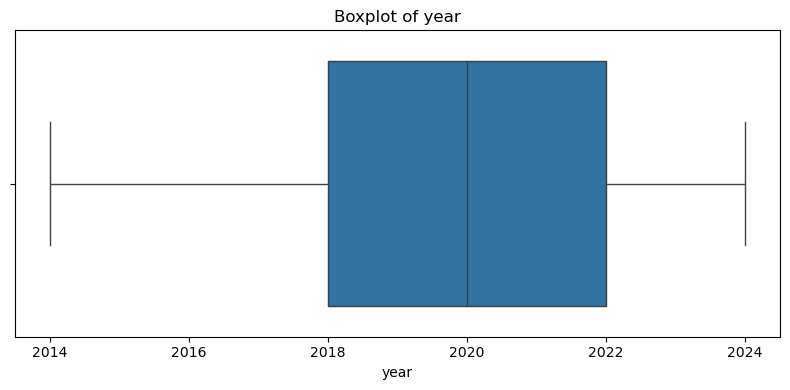

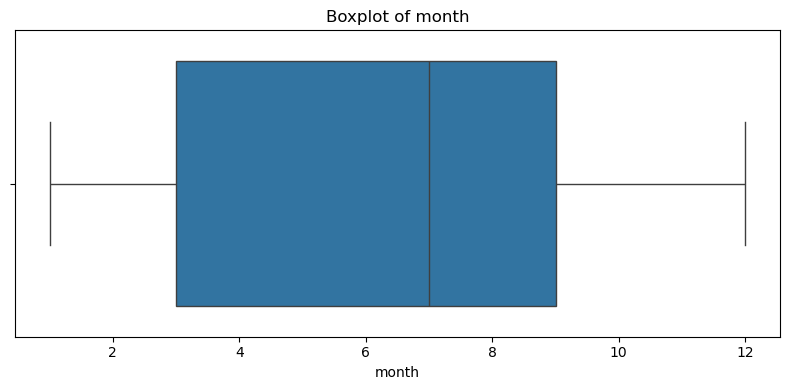

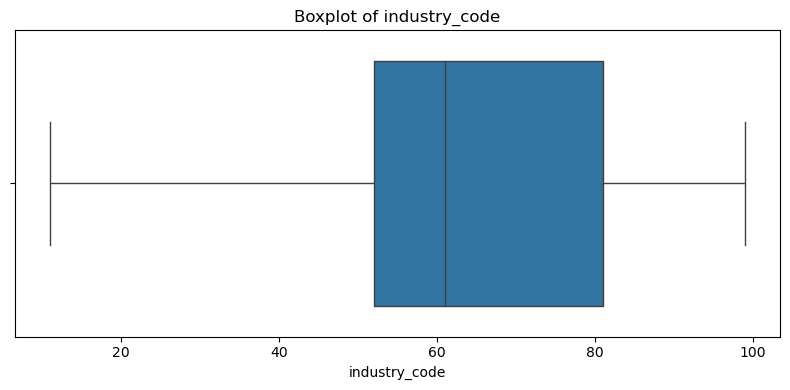

In [44]:
for col in numeric_columns:
    
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    
    plt.tight_layout()
    plt.show()

In [45]:
for col in numeric_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_count = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()
    
    print(
        f"{col}: {outlier_count} outliers"
    )

year: 0 outliers
month: 0 outliers
industry_code: 0 outliers


In [46]:
event_type_distribution = (
    df["event_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

event_type_distribution

event_type
Exploitive      49.75
Disruptive      31.22
Mixed           17.77
Undetermined     1.26
Name: proportion, dtype: float64

In [47]:
event_type_distribution = (
    df["event_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

event_type_distribution

event_type
Exploitive      49.75
Disruptive      31.22
Mixed           17.77
Undetermined     1.26
Name: proportion, dtype: float64

In [48]:
industry_distribution = (
    df["industry"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

industry_distribution.head(15)

industry
Public Administration                                                       19.75
Health Care and Social Assistance                                           13.72
Information                                                                 11.23
Finance and Insurance                                                        9.78
Educational Services                                                         9.65
Professional, Scientific, and Technical Services                             8.45
Manufacturing                                                                4.84
Retail Trade                                                                 3.54
Transportation and Warehousing                                               3.37
Arts, Entertainment, and Recreation                                          3.16
Other Services (except Public Administration)                                2.98
Accommodation and Food Services                                              2.20
Utiliti

### Category Imbalance

The categorical variables are not evenly distributed.

For example, Criminal actors account for approximately 76% of the recorded
actor types, while several other actor categories represent substantially
smaller proportions.

Similarly, Exploitive events account for approximately 50% of recorded
events.

This imbalance is not treated as a data error because it represents the
distribution present in the real-world event database. The categories are
retained so that the analysis reflects the actual observed cyber event
landscape.

In [49]:
df["event_subtype"] = df["event_subtype"].fillna("Unknown")
df["actor_country"] = df["actor_country"].fillna("Unknown")
df["source_url"] = df["source_url"].fillna("Not Available")
df["description"] = df["description"].fillna("Not Available")

In [50]:
df.isnull().sum()

slug             0
event_date       0
year             0
month            0
actor            0
actor_type       0
organization     0
industry_code    0
industry         0
motive           0
event_type       0
event_subtype    0
description      0
source_url       0
country          0
actor_country    0
dtype: int64

### Missing Values Handling

The dataset contained a very small number of missing values.

- `event_subtype` had 20 missing values (0.14%).
- `actor_country` had 5 missing values (0.04%).
- `source_url` had 4 missing values (0.03%).
- `description` had 2 missing values (0.01%).

Since these missing values represented a very small proportion of the dataset,
the corresponding records were not removed.

Instead, missing categorical/text values were replaced with meaningful labels
such as `Unknown` and `Not Available`. Mean or median imputation was not
appropriate because these variables are categorical or text-based.

This approach preserves the cyber-event records without introducing
potentially incorrect information.

In [51]:
df.duplicated().sum()

np.int64(0)

### Duplicate Records

Duplicate records were checked using the complete set of columns.

The dataset contains 13,841 records, and no completely duplicated rows were
found.

The `slug` column was also checked as the event identifier. All 13,841 slug
values are unique, with 0 duplicate slugs.

Therefore, no duplicate records were removed from the dataset.

In [52]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

df[numeric_columns].describe().T

Numerical columns:
['year', 'month', 'industry_code']


,count,mean,std,min,25%,50%,75%,max
year,13841.0,2019.833394,2.852742,2014.0,2018.0,2020.0,2022.0,2024.0
month,13841.0,6.419767,3.475130,1.0,3.0,7.0,9.0,12.0
industry_code,13841.0,63.245286,18.909945,11.0,52.0,61.0,81.0,99.0


### Outlier Treatment

The numerical columns in the dataset were examined to determine whether
outlier treatment was appropriate.

The dataset contains three numerical columns: `year`, `month`, and
`industry_code`.

- `year` ranges from 2014 to 2024 and represents the time period of the
  recorded cyber events. These values are valid observations rather than
  statistical outliers.
- `month` ranges from 1 to 12, which represents valid calendar months.
- `industry_code` is a numerical classification code rather than a
  continuous measurement. Therefore, statistical outlier techniques such
  as the IQR method are not meaningful for this variable.

Consequently, no observations were removed or modified as outliers.

This approach preserves legitimate cyber-event records and avoids treating
valid categorical codes or time values as erroneous observations.

"I checked the numerical columns, but they were not continuous measurement variables. Year and month represent time, while industry code is a categorical classification code. Therefore, applying IQR-based outlier removal would not be statistically meaningful, and I retained all valid observations."

# 4. Exploratory Data Analysis – Univariate Analysis

Univariate analysis is used to examine one variable at a time and understand
its distribution, frequency, and overall pattern.

For this analysis, categorical variables such as event type, actor type,
industry, motive, and event subtype are examined using count/bar plots.

The yearly distribution of cyber events is examined using a line plot to
understand how the number of recorded events changes over time.

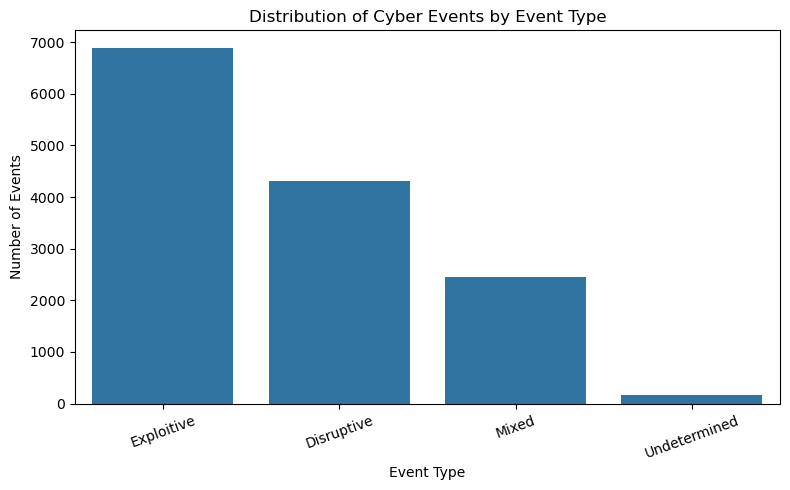

In [53]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="event_type",
    order=df["event_type"].value_counts().index
)

plt.title("Distribution of Cyber Events by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Why this plot?

A count plot is appropriate because event_type is categorical and we want to compare the number of events in each category.

### Observation and Insight

The distribution shows that **Exploitive** events represent the largest
category in the dataset, followed by **Disruptive** and **Mixed** events.
Undetermined events represent only a small proportion of the recorded events.

This indicates that exploitation-related cyber events form a major part of
the observed cyber threat landscape in the dataset.

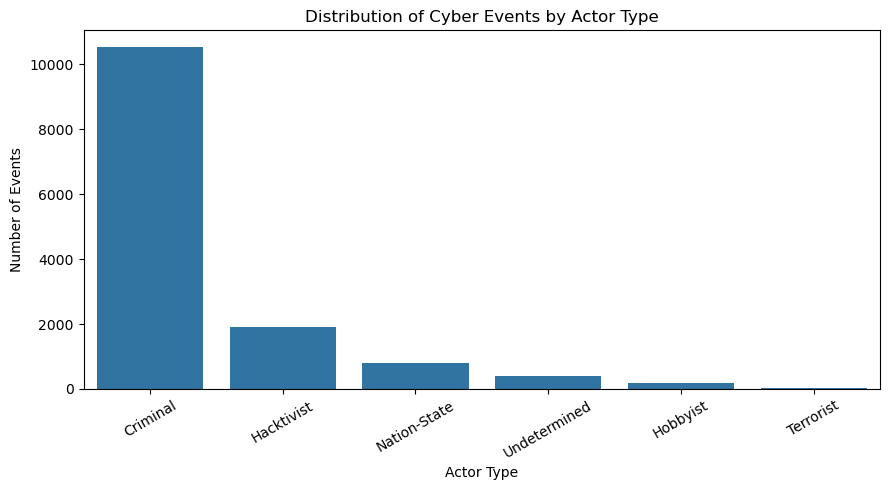

In [54]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="actor_type",
    order=df["actor_type"].value_counts().index
)

plt.title("Distribution of Cyber Events by Actor Type")
plt.xlabel("Actor Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Why this plot?

actor_type is a categorical variable that identifies the broad category of the threat actor. A count plot is suitable because we want to compare the frequency of different actor categories.

## What did we observe?

Criminal actors account for approximately 76% of the recorded actor types, making them substantially more common than the other categories.

Hacktivists and nation-state actors represent smaller proportions, while terrorist and hobbyist actors occur relatively infrequently.

Insight

The dataset is heavily represented by criminal-associated cyber events, suggesting that financially or criminally motivated activity forms a major portion of the recorded cyber events.

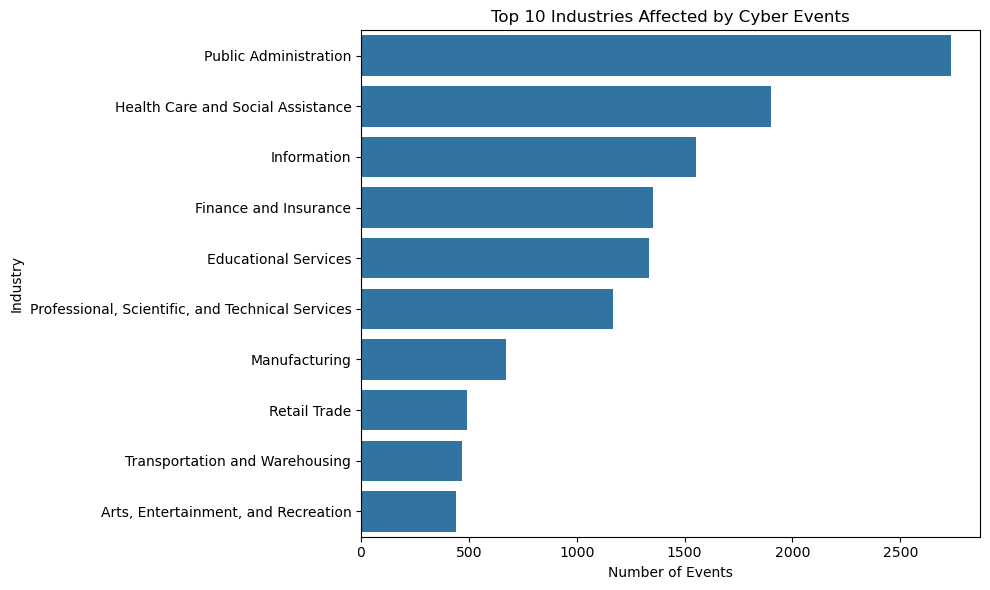

In [55]:
top_industries = df["industry"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_industries.values,
    y=top_industries.index
)

plt.title("Top 10 Industries Affected by Cyber Events")
plt.xlabel("Number of Events")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

## Why this plot?

industry contains many categories. Plotting every industry would make the visualization difficult to read.

Therefore, a horizontal bar chart of the top 10 industries is used to clearly compare which industries have the highest number of recorded cyber events.
## What did we observe?

The most frequently represented industry is Public Administration (19.75%), followed by:

Health Care and Social Assistance → 13.72%
Information → 11.23%
Finance and Insurance → 9.78%
Educational Services → 9.65%
Professional, Scientific, and Technical Services → 8.45%
Insight

Cyber events are concentrated in several critical and information-intensive sectors. Public Administration and Health Care together represent a substantial portion of the recorded events, highlighting the importance of cybersecurity in public and essential-service organizations.


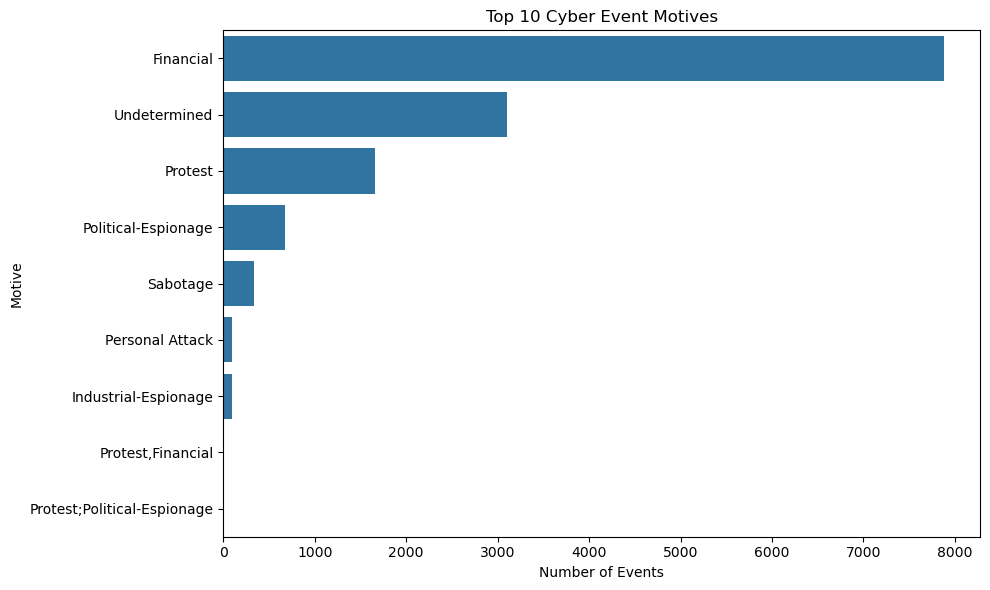

In [56]:
top_motives = df["motive"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_motives.values,
    y=top_motives.index
)

plt.title("Top 10 Cyber Event Motives")
plt.xlabel("Number of Events")
plt.ylabel("Motive")
plt.tight_layout()
plt.show()

## Why this plot?

motive is a categorical variable describing the reported/classified reason behind a cyber event. A bar chart allows us to compare the frequency of different motives.

Because there may be many motive categories, we'll use the top 10 to keep the visualization readable.
## What did we observe?
- Financial is the dominant motive with 7,881 events.
- Undetermined is the second-largest category with 3,104 events.
- Protest accounts for 1,662 events.
- Political-Espionage accounts for 670 events.
- Sabotage accounts for 337 events.
- Personal Attack and Industrial-Espionage are relatively rare.
- Two extremely small combined categories occur only once each.
## Insight

The dataset shows a strong concentration of cyber events associated with financial motives, indicating that financial gain is a major driver of the recorded cyber activity. The relatively large number of Undetermined motives also shows that the motivation behind some incidents could not be established from the available information.



In [57]:
df["motive"].value_counts()

motive
Financial                      7881
Undetermined                   3104
Protest                        1662
Political-Espionage             670
Sabotage                        337
Personal Attack                  93
Industrial-Espionage             92
Protest,Financial                 1
Protest;Political-Espionage       1
Name: count, dtype: int64

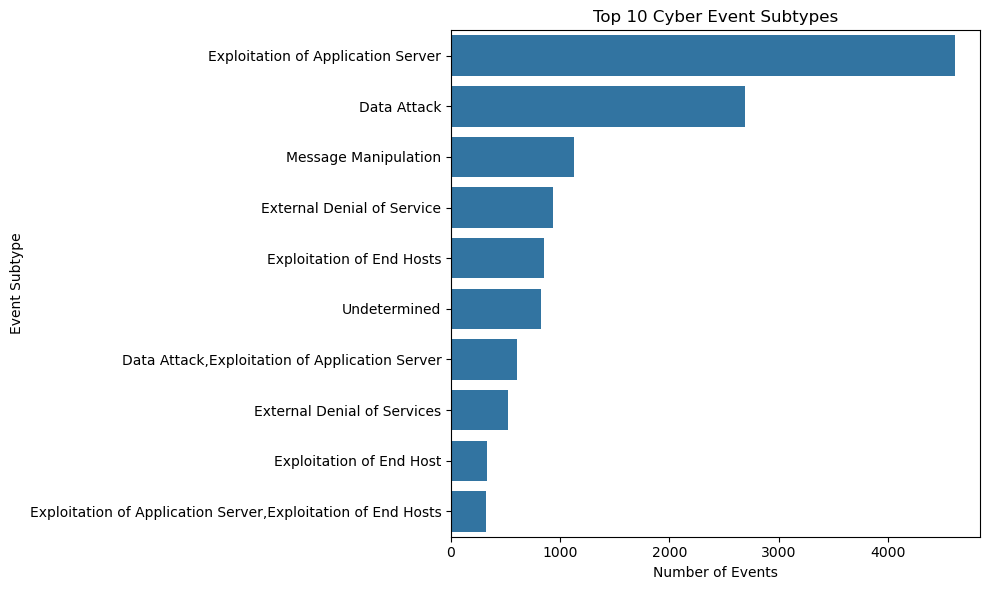

In [58]:
top_subtypes = df["event_subtype"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_subtypes.values,
    y=top_subtypes.index
)

plt.title("Top 10 Cyber Event Subtypes")
plt.xlabel("Number of Events")
plt.ylabel("Event Subtype")
plt.tight_layout()
plt.show()

## Why this plot?

event_subtype provides more detailed information than the broader event_type category.

A horizontal bar chart is used because there are many possible subtypes, and we want to compare the most frequently occurring ones without overcrowding the visualization.
## What did we observe?

The most frequent event subtype is:

- Exploitation of Application Server — 4,613
- Data Attack — 2,692
- Message Manipulation — 1,127
- External Denial of Service — 936
- Exploitation of End Hosts — 854
- Undetermined — 821

There are also combinations such as:

- Data Attack + Exploitation of Application Server — 602
= External Denial of Services — 524
- Exploitation of End Host — 333
= Exploitation of Application Server + Exploitation of End Hosts — 316
## Insight

Exploitation of Application Server is the most frequently recorded specific event subtype, indicating that application-server exploitation represents a major attack pattern within this dataset. Data attacks are also highly represented, showing that attacks involving information/data are another important component of the cyber-event landscape.

## Important data-quality observation:
There are slightly different labels such as "External Denial of Service" and "External Denial of Services", and "Exploitation of End Hosts" vs "Exploitation of End Host". We should consider standardizing these later as part of categorical data cleaning if they represent the same concept.


In [59]:
df["event_subtype"].value_counts().head(10)

event_subtype
Exploitation of Application Server                              4613
Data Attack                                                     2692
Message Manipulation                                            1127
External Denial of Service                                       936
Exploitation of End Hosts                                        854
Undetermined                                                     821
Data Attack,Exploitation of Application Server                   602
External Denial of Services                                      524
Exploitation of End Host                                         333
Exploitation of Application Server,Exploitation of End Hosts     316
Name: count, dtype: int64

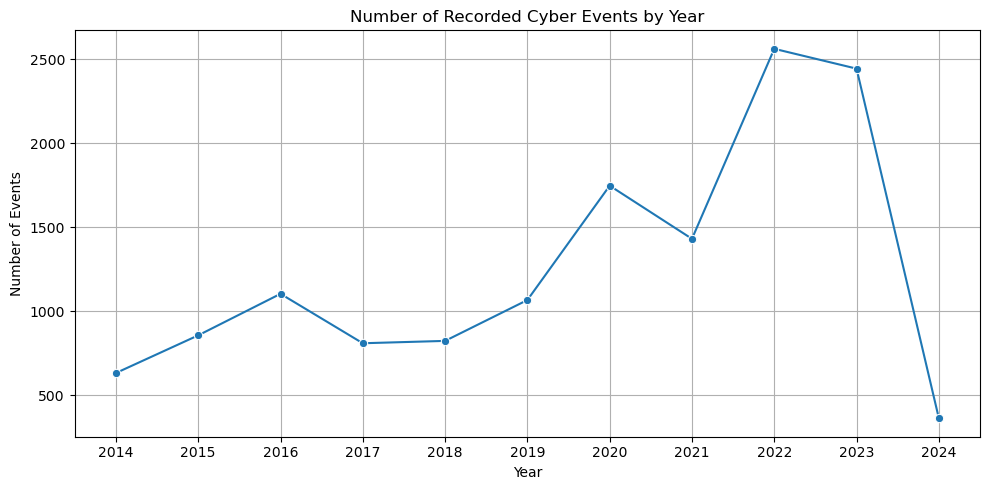

In [60]:
yearly_events = df["year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=yearly_events.index,
    y=yearly_events.values,
    marker="o"
)

plt.title("Number of Recorded Cyber Events by Year")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.xticks(yearly_events.index)
plt.grid(True)
plt.tight_layout()
plt.show()

## Why this plot?

year is a time-based variable. A line plot is appropriate because it shows the chronological progression of recorded cyber events and makes increases, decreases, peaks, and fluctuations easier to identify.

## What did we observe?
Year	Events
2014	633
2015	857
2016	1,104
2017	810
2018	824
2019	1,067
2020	1,747
2021	1,431
2022	2,561
2023	2,443
2024	364

The major pattern is:

- Events generally increased from 2014 to 2016.
- There was a decline in 2017, followed by relatively stable levels in 2018.
- Events increased again from 2019.
- A significant rise occurred in 2020.
- There was a small decline in 2021.
- The dataset reaches its highest recorded level in 2022 with 2,561 events.
- 2023 remained very high at 2,443 events.
- 2024 has only 364 events, which is substantially lower than 2022–2023.
## Insight

The recorded cyber events show an overall increasing trend over the earlier years, with particularly high levels during 2020–2023. The peak occurs in 2022.

In [61]:
df["year"].value_counts().sort_index()

year
2014     633
2015     857
2016    1104
2017     810
2018     824
2019    1067
2020    1747
2021    1431
2022    2561
2023    2443
2024     364
Name: count, dtype: int64

### Univariate Analysis – Key Findings

The univariate analysis revealed several important characteristics of the cyber-event dataset:

- Exploitive events represent the largest event type, followed by Disruptive and Mixed events.
- Criminal actors account for the majority of recorded threat actors.
- Public Administration, Health Care and Social Assistance, and Information are among the most frequently affected industries.
- Financial motivation is the dominant recorded motive.
- Exploitation of Application Server is the most frequently recorded event subtype.
- The number of recorded events generally increased over time, with particularly high levels between 2020 and 2023.
- 2022 recorded the highest number of events in the dataset.
- The sharp decline in 2024 should be interpreted cautiously because the available data for that year may represent incomplete coverage rather than an actual reduction in cyber activity.

Overall, the univariate analysis indicates that the dataset is highly concentrated around specific actor types, motives, industries, and attack patterns, providing a strong foundation for investigating relationships between these variables in the next stage.

In [62]:
print("Actor Type:")
print(df["actor_type"].value_counts())

print("\nEvent Subtype:")
print(df["event_subtype"].value_counts())

Actor Type:
actor_type
Criminal        10523
Hacktivist       1907
Nation-State      790
Undetermined      402
Hobbyist          189
Terrorist          30
Name: count, dtype: int64

Event Subtype:
event_subtype
Exploitation of Application Server                                                             4613
Data Attack                                                                                    2692
Message Manipulation                                                                           1127
External Denial of Service                                                                      936
Exploitation of End Hosts                                                                       854
                                                                                               ... 
Data Attack,Physical Attack                                                                       1
Exploitation of Application Server,Message Manipulation,Exploitation of Data in Transit  

### Categorical Consistency Check

Categorical variables were examined for inconsistent or duplicate-looking labels.

The `actor_type` variable contains six major categories: Criminal, Hacktivist, Nation-State, Undetermined, Hobbyist, and Terrorist. No further standardization was required.

The `event_subtype` variable contains 87 distinct categories. Some records contain multiple event subtypes combined within a single value, representing events involving more than one type of activity. These values were retained because splitting or merging them without additional domain validation could alter the original meaning of the records.

Therefore, no additional categorical values were modified at this stage.

In [63]:
# Cross-tabulation of Event Type and Actor Type
event_actor = pd.crosstab(
    df["actor_type"],
    df["event_type"]
)

event_actor

event_type,Disruptive,Exploitive,Mixed,Undetermined
actor_type,,,,
Criminal,2451,5578,2333,161
Hacktivist,1384,445,69,9
Hobbyist,139,46,4,0
Nation-State,253,498,35,4
Terrorist,5,25,0,0
Undetermined,89,294,19,0


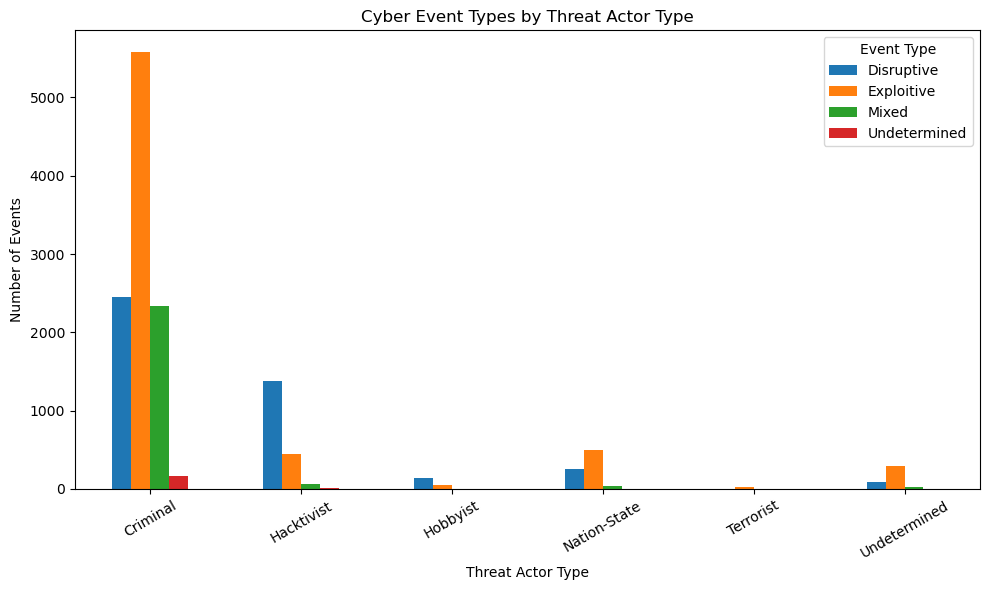

In [65]:
event_actor.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cyber Event Types by Threat Actor Type")
plt.xlabel("Threat Actor Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=30)
plt.legend(title="Event Type")
plt.tight_layout()
plt.show()

### Why this plot?

A grouped bar chart is used to compare two categorical variables: `actor_type` and `event_type`.

The chart helps identify how different types of cyber events are distributed across different threat actor groups. Comparing the categories side by side makes it easier to determine whether certain event types are more commonly associated with particular actor types.

### What did we observe?

- Criminal actors account for the highest number of cyber events, with Exploitive events being their most frequent event type.
- Hacktivists show a strong concentration of Disruptive events compared with Exploitive events.
- Nation-State actors have more Exploitive events than Disruptive events.
- Hobbyists also show a higher number of Disruptive events.
- Terrorist-related events represent a very small proportion of the dataset.
- Undetermined actors are more frequently associated with Exploitive events.

### Key Insight

The distribution of event types varies across threat actor groups. Criminal actors dominate the dataset and are mainly associated with Exploitive events, whereas Hacktivists show a much stronger association with Disruptive events. This indicates that different threat actor groups may exhibit different patterns of cyber activity.

In [66]:
top_industries = df["industry"].value_counts().head(10).index

industry_event = pd.crosstab(
    df[df["industry"].isin(top_industries)]["industry"],
    df[df["industry"].isin(top_industries)]["event_type"]
)

industry_event

event_type,Disruptive,Exploitive,Mixed,Undetermined
industry,,,,
"Arts, Entertainment, and Recreation",163,227,44,4
Educational Services,441,594,277,23
Finance and Insurance,310,852,177,14
Health Care and Social Assistance,340,1088,446,25
Information,608,788,148,11
Manufacturing,176,209,276,9
"Professional, Scientific, and Technical Services",190,648,322,9
Public Administration,1287,1089,316,41
Retail Trade,60,337,86,7


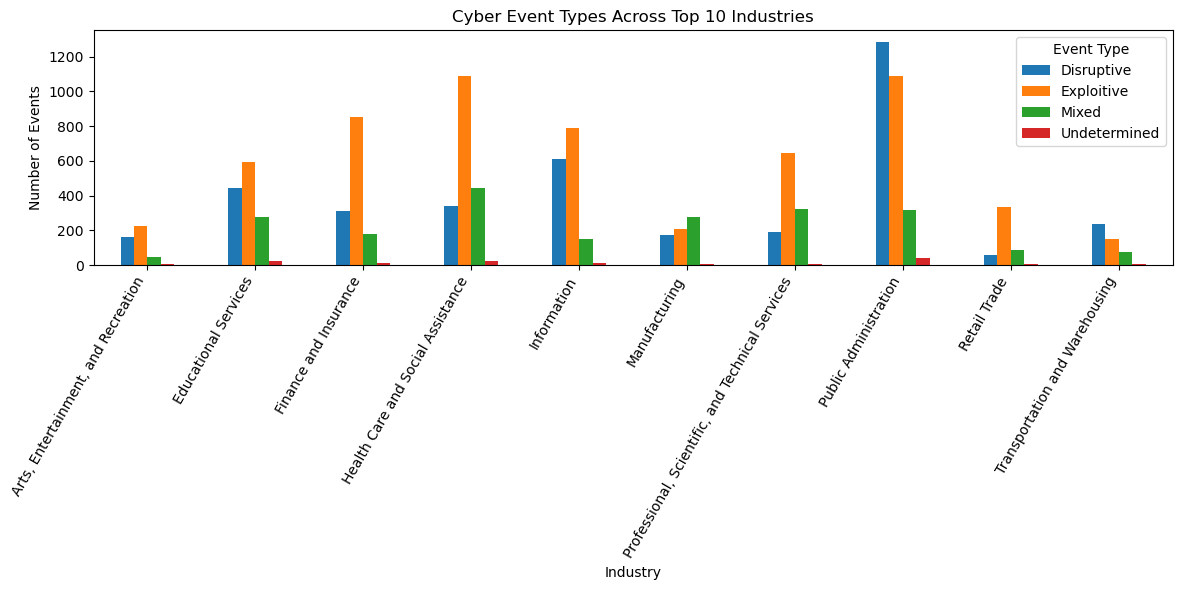

In [68]:
industry_event.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cyber Event Types Across Top 10 Industries")
plt.xlabel("Industry")
plt.ylabel("Number of Events")
plt.xticks(rotation=60, ha="right")
plt.legend(title="Event Type")
plt.tight_layout()
plt.show()

### Why this plot?

A grouped bar chart is used to compare `industry` and `event_type`.

The top 10 industries are selected because the dataset contains many industry categories. Focusing on the most frequently affected industries makes the comparison easier to interpret while highlighting where different types of cyber events occur most often.
What did we observe?

Use the actual chart to describe the exact differences. But based on the dataset structure, focus on:

Which industries have the highest total number of events.
Whether Exploitive or Disruptive events dominate within each major industry.
Whether certain industries show a noticeably different event-type pattern.
Markdown:
### What did we observe?

- Public Administration has the highest overall number of recorded events among the top industries.
- Health Care and Social Assistance and Information are also heavily represented.
- Exploitive events form a major portion of events across several of the leading industries.
- Disruptive events are also significant in some industries.
- The distribution of event types is not identical across industries, indicating differences in the nature of cyber activity affecting different sectors.
Key Insight
### Key Insight

Cyber event patterns vary across industries. Public Administration, Health Care and Social As

In [69]:
motive_event = pd.crosstab(
    df["motive"],
    df["event_type"]
)

motive_event

event_type,Disruptive,Exploitive,Mixed,Undetermined
motive,,,,
Financial,1481,4068,2243,89
Industrial-Espionage,0,90,2,0
Personal Attack,27,64,2,0
Political-Espionage,7,631,29,3
Protest,1258,345,50,9
"Protest,Financial",0,0,1,0
Protest;Political-Espionage,0,1,0,0
Sabotage,271,42,23,1
Undetermined,1277,1645,110,72


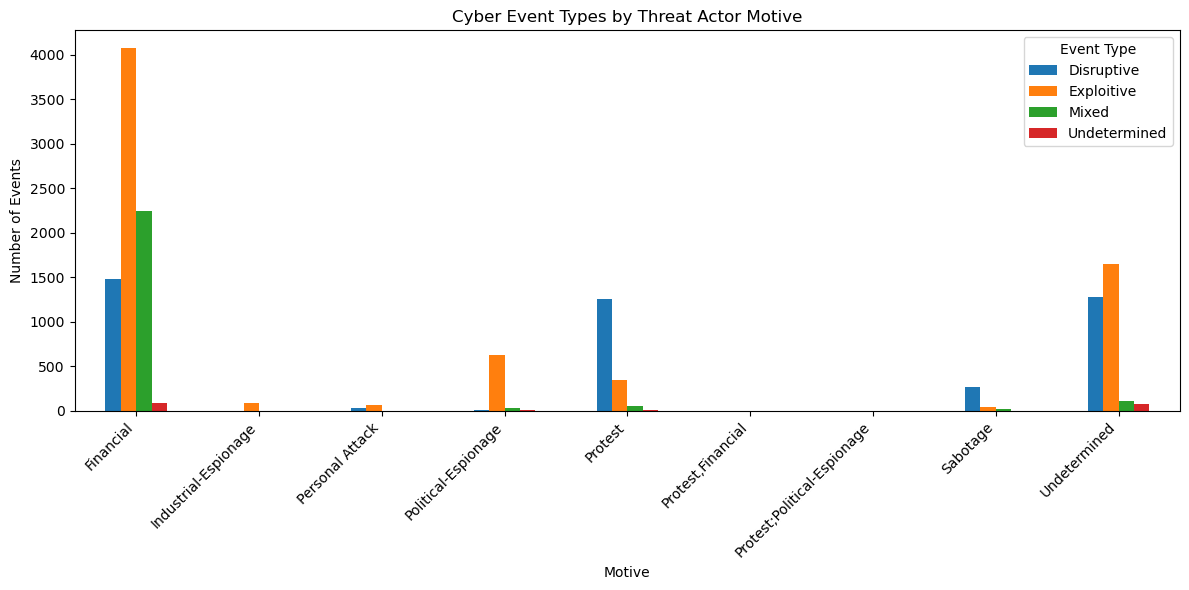

In [70]:
motive_event.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cyber Event Types by Threat Actor Motive")
plt.xlabel("Motive")
plt.ylabel("Number of Events")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Event Type")
plt.tight_layout()
plt.show()


### Why this plot?

A grouped bar chart is used to examine the relationship between `motive` and `event_type`.

The visualization helps determine whether different motivations, such as Financial, Protest, Political-Espionage, or Sabotage, are associated with different types of cyber events.
What did we observe?

-Financial is the dominant motive.
- Undetermined is the second-largest motive category.
- Protest is another major motive.
- Financially motivated events have a strong presence of Exploitive activity.
- Protest-related activity is expected to show a stronger Disruptive pattern.

### What did we observe?

- Financial is the most frequently recorded motive.
- Undetermined is the second-largest motive category.
- Protest is another important motive in the dataset.
- Financially motivated events show a strong presence of Exploitive events.
- Protest-related events show a relatively stronger presence of Disruptive activity.
- Less frequent motives such as Sabotage and Political-Espionage contribute fewer events overall.
Key Insight
### Key Insight

The relationship between motive and event type suggests that the objective behind a cyber event is associated with the type of activity carried out. Financial motives are strongly represented among Exploitive events, while protest-oriented activity is more closely associated with disruptive behavior. Understanding the motivation behind attacks can therefore help organizations anticipate likely attack patterns.

In [71]:
industry_actor = pd.crosstab(
    df["industry"],
    df["actor_type"]
)

top_industries = df["industry"].value_counts().head(10).index

industry_actor_top = industry_actor.loc[
    industry_actor.index.intersection(top_industries)
]

industry_actor_top

actor_type,Criminal,Hacktivist,Hobbyist,Nation-State,Terrorist,Undetermined
industry,,,,,,
"Arts, Entertainment, and Recreation",329,25,53,9,1,21
Educational Services,1160,73,15,27,1,59
Finance and Insurance,1096,170,7,64,0,16
Health Care and Social Assistance,1825,39,3,19,0,13
Information,1056,228,34,122,14,101
Manufacturing,540,80,6,32,0,12
"Professional, Scientific, and Technical Services",1012,56,12,43,0,46
Public Administration,1495,871,25,272,8,62
Retail Trade,445,8,4,14,0,19


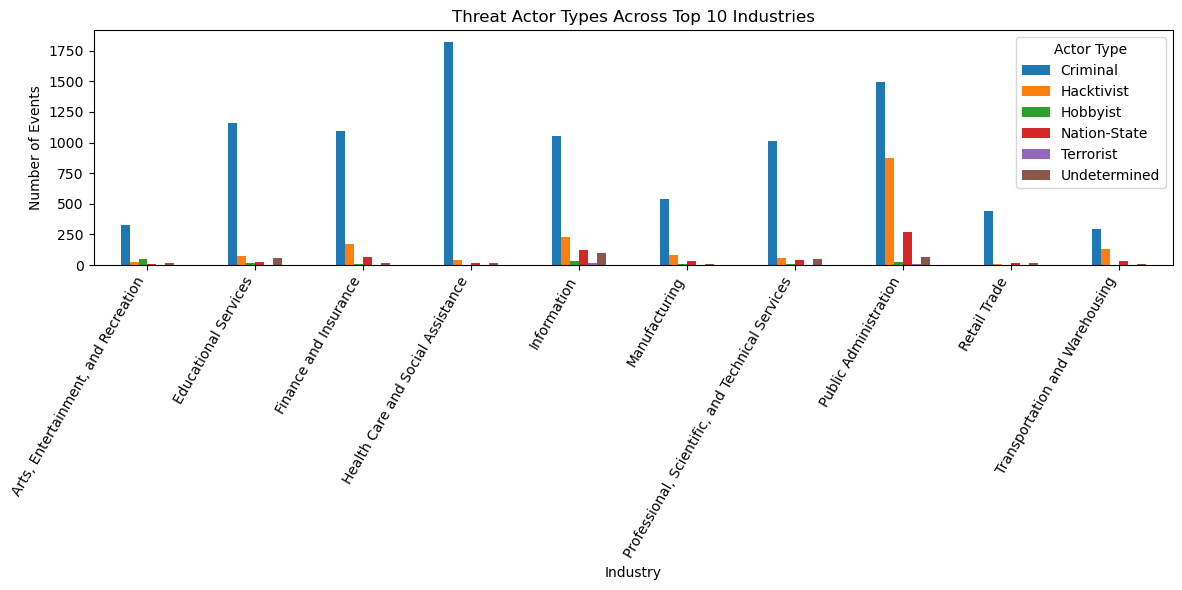

In [72]:
industry_actor_top.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Threat Actor Types Across Top 10 Industries")
plt.xlabel("Industry")
plt.ylabel("Number of Events")
plt.xticks(rotation=60, ha="right")
plt.legend(title="Actor Type")
plt.tight_layout()
plt.show()


### Why this plot?

A grouped bar chart is used to compare `industry` and `actor_type`.

This analysis helps identify which types of threat actors are most frequently associated with major industry sectors. The top 10 industries are used to improve readability and focus on the sectors with the largest number of recorded cyber events.
What did we observe?
### What did we observe?

- Criminal actors appear across most of the major industries and account for the largest number of events.
- Several major industries show a noticeable presence of Hacktivist activity.
- Nation-State activity is smaller than Criminal activity but appears across multiple sectors.
- The composition of threat actors differs between industries.
Key Insight
### Key Insight

Criminal actors represent the dominant threat actor group across the major industries in the dataset. However, the presence of Hacktivists and Nation-State actors varies across sectors. This indicates that organizations may face different threat profiles depending on their industry and should consider sector-specific threat intelligence when assessing cybersecurity risks.

In [73]:
year_event = pd.crosstab(
    df["year"],
    df["event_type"]
)

year_event

event_type,Disruptive,Exploitive,Mixed,Undetermined
year,,,,
2014,262,358,13,0
2015,316,509,32,0
2016,445,628,30,1
2017,360,422,28,0
2018,205,599,20,0
2019,414,614,39,0
2020,561,901,283,2
2021,397,597,405,32
2022,892,940,671,58


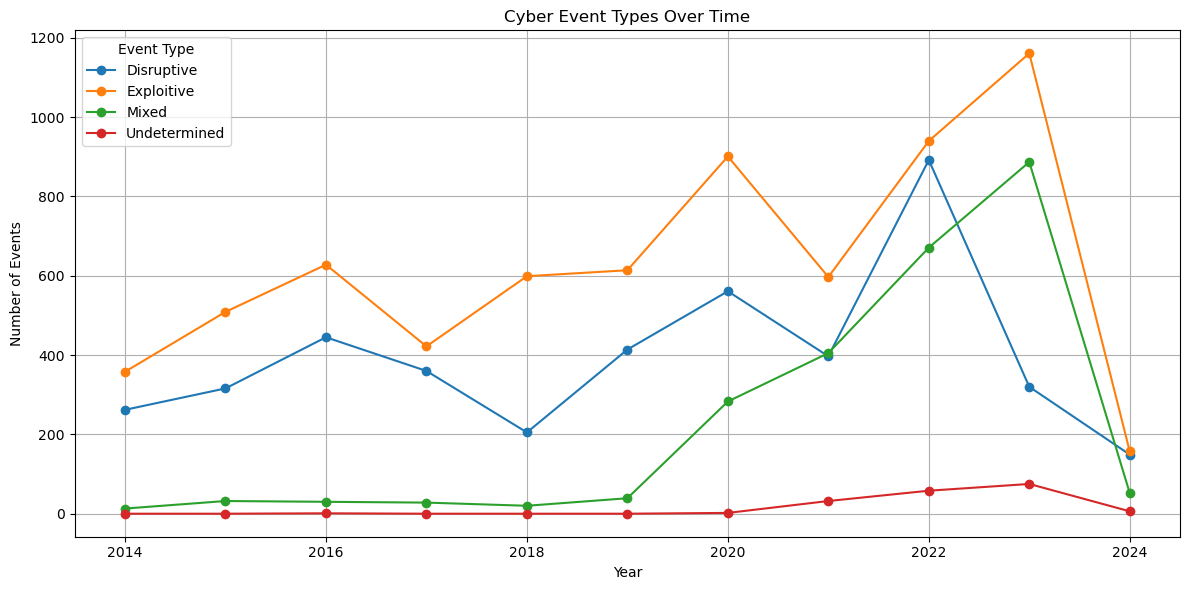

In [74]:
year_event.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Cyber Event Types Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.legend(title="Event Type")
plt.grid(True)
plt.tight_layout()
plt.show()

Why this plot?
### Why this plot?

A line chart is appropriate because `year` is a time-based variable and `event_type` is categorical.

The visualization shows how different types of cyber events changed over time and helps identify periods of increasing activity, peaks, and changes in the composition of cyber events.
What did we observe?

Your yearly totals already show:

2014 → 633
2015 → 857
2016 → 1,104
2020 → 1,747
2021 → 1,431
2022 → 2,561
2023 → 2,443
2024 → 364

For the event-type lines, describe which category is highest in each period after seeing your chart.

### What did we observe?

- Overall cyber-event activity increased across the earlier years of the dataset.
- Exploitive events remain an important component of recorded activity across the timeline.
- Disruptive and Mixed events also contribute substantially to the yearly totals.
- Cyber-event activity reaches its highest overall level around 2022 and remains high in 2023.
- The sharp decline in 2024 should be interpreted cautiously because the available data for 2024 may not represent a complete year of observations.
Key Insight
### Key Insight

Cyber-event activity shows substantial variation over time, with particularly high levels during 2020–2023 and a peak in 2022. Examining event types over time helps identify changing patterns in cyber activity and can support time-based cybersecurity monitoring and preparedness.

In [75]:
year_actor = pd.crosstab(
    df["year"],
    df["actor_type"]
)

year_actor

actor_type,Criminal,Hacktivist,Hobbyist,Nation-State,Terrorist,Undetermined
year,,,,,,
2014,348,222,26,6,1,30
2015,420,241,30,35,4,127
2016,578,342,29,33,4,118
2017,549,36,24,182,0,19
2018,700,31,3,78,2,10
2019,914,47,19,74,1,12
2020,1523,33,35,87,1,68
2021,1344,14,3,52,15,3
2022,1792,658,11,94,0,6


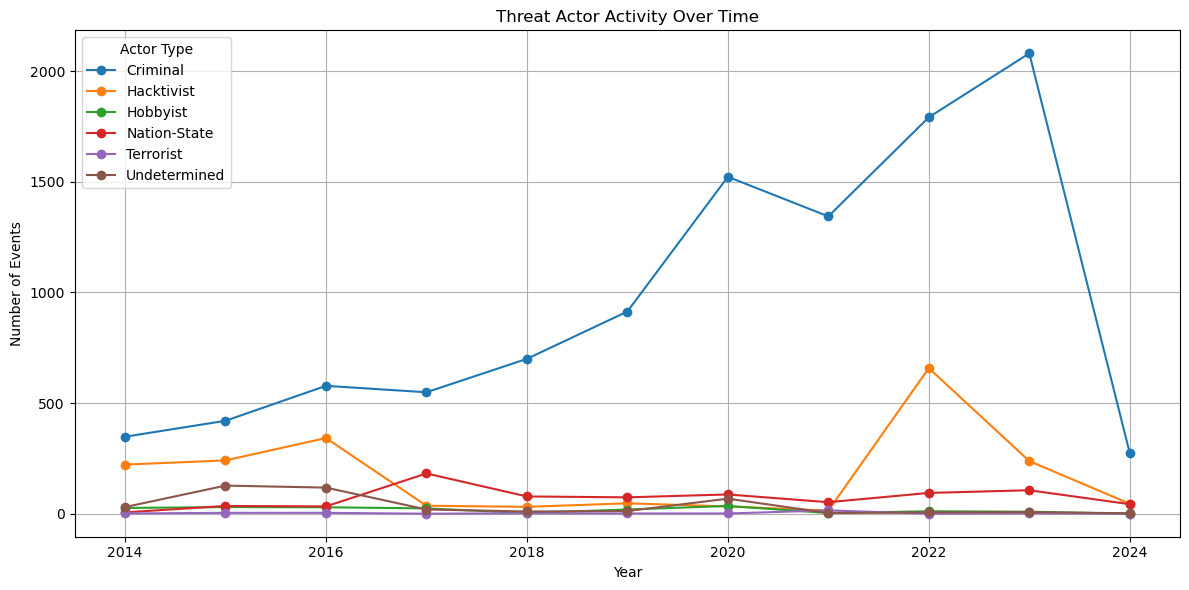

In [76]:
year_actor.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Threat Actor Activity Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.legend(title="Actor Type")
plt.grid(True)
plt.tight_layout()
plt.show()

Why this plot?
### Why this plot?

A line chart is used to examine the relationship between `year` and `actor_type`.

Since year represents a chronological variable, the line chart makes it easier to observe how activity associated with different threat actor groups changes over time. This can help identify periods of increased activity and changing threat-actor patterns.
What did we observe?
### What did we observe?

- Criminal actors consistently account for the largest share of recorded cyber events across the dataset.
- Hacktivist activity is substantially lower than Criminal activity but contributes a noticeable number of events.
- Nation-State activity is comparatively smaller and varies across years.
- Hobbyist and Terrorist-related events remain relatively limited in comparison with the major actor categories.
- The overall number of events associated with major actor groups increases during the high-activity years of the dataset.
Key Insight
### Key Insight

The threat landscape is dominated by Criminal actors throughout the dataset, while Hacktivist and Nation-State activity represents smaller but distinct components of the cyber-event landscape. Monitoring changes in threat actor activity over time can help organizations understand how their potential threat environment evolves.

## 5. EDA – Bivariate Analysis

Bivariate analysis examines relationships between two variables to identify important patterns in the cybersecurity event data.

### 5.1 Event Type × Actor Type

- Criminal actors recorded the highest number of events, mainly Exploitive events.
- Hacktivists showed a stronger association with Disruptive events.
- The distribution of event types varied across threat actor groups.

### Key Insight

- Different threat actors exhibit different patterns of cyber activity.

---

### 5.2 Industry × Event Type

- Public Administration had the highest number of recorded events among the major industries.
- Health Care, Information, Finance, and Education were also highly affected.
- The proportion of event types varied across industries.

### Key Insight

- Cybersecurity risks and attack patterns differ across industry sectors.

---

### 5.3 Motive × Event Type

- Financial was the most common motive, followed by Undetermined and Protest.
- Financial motives were strongly represented among Exploitive events.
- Protest activity showed a stronger presence of Disruptive events.

### Key Insight

- Attacker motivation is associated with the type of cyber activity carried out.

---

### 5.4 Industry × Actor Type

- Criminal actors were dominant across the major industries.
- Hacktivist and Nation-State activity appeared at lower levels across several sectors.
- Threat-actor composition varied between industries.

### Key Insight

- Different industries can face different threat-actor profiles.

---

### 5.5 Year × Event Type

- Cyber-event activity increased significantly during the later years.
- Recorded activity was particularly high during 2020–2023.
- 2022 recorded the highest overall number of events.
- The decline in 2024 should be interpreted cautiously due to potentially incomplete coverage.

### Key Insight

- Cyber activity has changed considerably over time, highlighting the importance of continuous threat monitoring.

---

### 5.6 Year × Actor Type

- Criminal actors consistently represented the largest threat-actor group.
- Hacktivist and Nation-State activity formed smaller but distinct categories.
- Threat-actor activity varied across different years.

### Key Insight

- Monitoring threat-actor trends over time can help organizations understand changes in the cybersecurity landscape.

---

## Bivariate Analysis – Summary

- Criminal actors and Exploitive events dominate the dataset.
- Financial motivation is the most common motive.
- Public Administration, Health Care, Information, Finance, and Education are major affected sectors.
- Attack patterns vary by actor, motive, industry, and year.
- Cyber-event activity was particularly high during 2020–2023.
- These relationships provide a foundation for deeper multivariate analysis.

## 6. EDA – Multivariate Analysis

In [77]:
year_event_actor = (
    df.groupby(["year", "actor_type", "event_type"])
      .size()
      .reset_index(name="event_count")
)

year_event_actor.head(20)

,year,actor_type,event_type,event_count
0,2014,Criminal,Disruptive,72
1,2014,Criminal,Exploitive,275
2,2014,Criminal,Mixed,1
3,2014,Hacktivist,Disruptive,160
4,2014,Hacktivist,Exploitive,53
5,2014,Hacktivist,Mixed,9
6,2014,Hobbyist,Disruptive,20
7,2014,Hobbyist,Exploitive,5
8,2014,Hobbyist,Mixed,1
9,2014,Nation-State,Exploitive,5


In [78]:
year_event_actor_pivot = pd.pivot_table(
    year_event_actor,
    index="year",
    columns=["actor_type", "event_type"],
    values="event_count",
    fill_value=0
)

year_event_actor_pivot

actor_type   Criminal                                Hacktivist             \
event_type Disruptive Exploitive  Mixed Undetermined Disruptive Exploitive   
year                                                                         
2014             72.0      275.0    1.0          0.0      160.0       53.0   
2015            111.0      294.0   15.0          0.0      171.0       56.0   
2016            146.0      421.0   11.0          0.0      240.0       89.0   
2017            159.0      369.0   21.0          0.0       26.0        9.0   
2018            170.0      514.0   16.0          0.0       21.0        7.0   
2019            361.0      524.0   29.0          0.0       23.0       15.0   
2020            485.0      761.0  275.0          2.0       17.0       16.0   
2021            372.0      536.0  404.0         32.0        4.0        9.0   
2022            344.0      741.0  654.0         53.0      516.0      131.0   
2023            132.0     1018.0  863.0         68.0      173.0       49.0   
2024             99.0      125.0   44.0          6.0       33.0       11.0   

actor_type                      Hobbyist                  Nation-State  \
event_type Mixed Undetermined Disruptive Exploitive Mixed   Disruptive   
year                                                                     
2014         9.0          0.0       20.0        5.0   1.0          0.0   
2015        14.0          0.0       16.0       13.0   1.0          2.0   
2016        12.0          1.0       22.0        6.0   1.0          3.0   
2017         1.0          0.0       20.0        3.0   1.0        148.0   
2018         3.0          0.0        2.0        1.0   0.0          7.0   
2019         9.0          0.0       16.0        3.0   0.0          8.0   
2020         0.0          0.0       33.0        2.0   0.0         17.0   
2021         1.0          0.0        2.0        1.0   0.0         17.0   
2022         9.0          2.0        8.0        3.0   0.0         23.0   
2023        10.0          6.0        0.0        9.0   0.0         13.0   
2024         1.0          0.0        0.0        0.0   0.0         15.0   

actor_type                                Terrorist            Undetermined  \
event_type Exploitive Mixed Undetermined Disruptive Exploitive   Disruptive   
year                                                                          
2014              5.0   1.0          0.0        1.0        0.0          9.0   
2015             33.0   0.0          0.0        0.0        4.0         16.0   
2016             29.0   1.0          0.0        2.0        2.0         32.0   
2017             31.0   3.0          0.0        0.0        0.0          7.0   
2018             70.0   1.0          0.0        0.0        2.0          5.0   
2019             65.0   1.0          0.0        1.0        0.0          5.0   
2020             69.0   1.0          0.0        0.0        1.0          9.0   
2021             35.0   0.0          0.0        0.0       15.0          2.0   
2022             62.0   6.0          3.0        0.0        0.0          1.0   
2023             78.0  14.0          1.0        1.0        1.0          1.0   
2024             21.0   7.0          0.0        0.0        0.0          2.0   

actor_type                   
event_type Exploitive Mixed  
year                         
2014             20.0   1.0  
2015            109.0   2.0  
2016             81.0   5.0  
2017             10.0   2.0  
2018              5.0   0.0  
2019              7.0   0.0  
2020             52.0   7.0  
2021              1.0   0.0  
2022              3.0   2.0  
2023              6.0   0.0  
2024              0.0   0.0

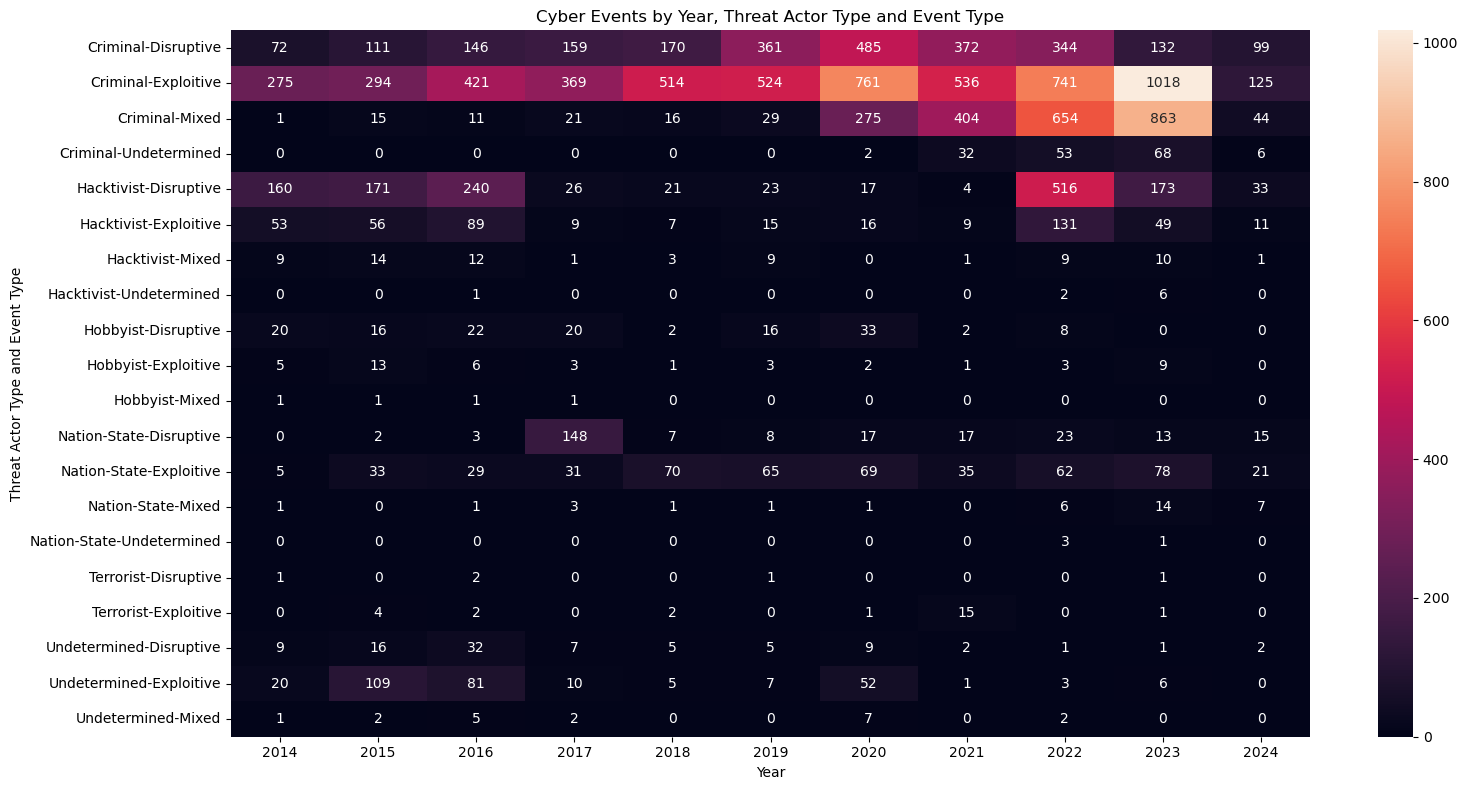

In [79]:
plt.figure(figsize=(16, 8))

sns.heatmap(
    year_event_actor_pivot.T,
    annot=True,
    fmt="g"
)

plt.title("Cyber Events by Year, Threat Actor Type and Event Type")
plt.xlabel("Year")
plt.ylabel("Threat Actor Type and Event Type")
plt.tight_layout()
plt.show()

### Observation
- Criminal actors consistently recorded the highest number of events, especially Exploitive events.
- Criminal Exploitive events increased strongly over time and reached the highest level in 2023.
- Hacktivists showed a stronger presence in Disruptive events, particularly in 2022.
- Nation-State activity remained lower overall but showed noticeable increases in some years.
- Recorded activity declined sharply in 2024, which may reflect incomplete data coverage.

### Key Insight
- Cyber activity patterns change over time and differ by threat actor, with Criminal actors dominating Exploitive activity and Hacktivists showing stronger Disruptive activity.

In [80]:
top_industries = df["industry"].value_counts().head(10).index

industry_event_actor = (
    df[df["industry"].isin(top_industries)]
    .groupby(["industry", "actor_type", "event_type"])
    .size()
    .reset_index(name="event_count")
)

industry_event_actor.head(20)

,industry,actor_type,event_type,event_count
0,"Arts, Entertainment, and Recreation",Criminal,Disruptive,84
1,"Arts, Entertainment, and Recreation",Criminal,Exploitive,201
2,"Arts, Entertainment, and Recreation",Criminal,Mixed,40
3,"Arts, Entertainment, and Recreation",Criminal,Undetermined,4
4,"Arts, Entertainment, and Recreation",Hacktivist,Disruptive,18
5,"Arts, Entertainment, and Recreation",Hacktivist,Exploitive,6
6,"Arts, Entertainment, and Recreation",Hacktivist,Mixed,1
7,"Arts, Entertainment, and Recreation",Hobbyist,Disruptive,51
8,"Arts, Entertainment, and Recreation",Hobbyist,Exploitive,2
9,"Arts, Entertainment, and Recreation",Nation-State,Disruptive,1


In [81]:
industry_event_actor_pivot = pd.pivot_table(
    industry_event_actor,
    index="industry",
    columns=["actor_type", "event_type"],
    values="event_count",
    fill_value=0
)

industry_event_actor_pivot

actor_type                                         Criminal                    \
event_type                                       Disruptive Exploitive  Mixed   
industry                                                                        
Arts, Entertainment, and Recreation                    84.0      201.0   40.0   
Educational Services                                  361.0      506.0  270.0   
Finance and Insurance                                 143.0      775.0  166.0   
Health Care and Social Assistance                     303.0     1058.0  439.0   
Information                                           337.0      597.0  113.0   
Manufacturing                                          90.0      167.0  274.0   
Professional, Scientific, and Technical Services      156.0      535.0  314.0   
Public Administration                                 582.0      598.0  279.0   
Retail Trade                                           47.0      305.0   86.0   
Transportation and Warehousing                         85.0      129.0   69.0   

actor_type                                                    Hacktivist  \
event_type                                       Undetermined Disruptive   
industry                                                                   
Arts, Entertainment, and Recreation                       4.0       18.0   
Educational Services                                     23.0       49.0   
Finance and Insurance                                    12.0      137.0   
Health Care and Social Assistance                        25.0       25.0   
Information                                               9.0      147.0   
Manufacturing                                             9.0       68.0   
Professional, Scientific, and Technical Services          7.0       19.0   
Public Administration                                    36.0      629.0   
Retail Trade                                              7.0        4.0   
Transportation and Warehousing                            8.0      121.0   

actor_type                                                         \
event_type                                       Exploitive Mixed   
industry                                                            
Arts, Entertainment, and Recreation                     6.0   1.0   
Educational Services                                   20.0   4.0   
Finance and Insurance                                  24.0   7.0   
Health Care and Social Assistance                       8.0   6.0   
Information                                            62.0  17.0   
Manufacturing                                          12.0   0.0   
Professional, Scientific, and Technical Services       35.0   1.0   
Public Administration                                 214.0  26.0   
Retail Trade                                            4.0   0.0   
Transportation and Warehousing                          8.0   2.0   

actor_type                                                      Hobbyist  \
event_type                                       Undetermined Disruptive   
industry                                                                   
Arts, Entertainment, and Recreation                       0.0       51.0   
Educational Services                                      0.0        8.0   
Finance and Insurance                                     2.0        5.0   
Health Care and Social Assistance                         0.0        2.0   
Information                                               2.0       28.0   
Manufacturing                                             0.0        4.0   
Professional, Scientific, and Technical Services          1.0        8.0   
Public Administration                                     2.0       15.0   
Retail Trade                                              0.0        0.0   
Transportation and Warehousing                            1.0        0.0   

actor_type                                                         \
e

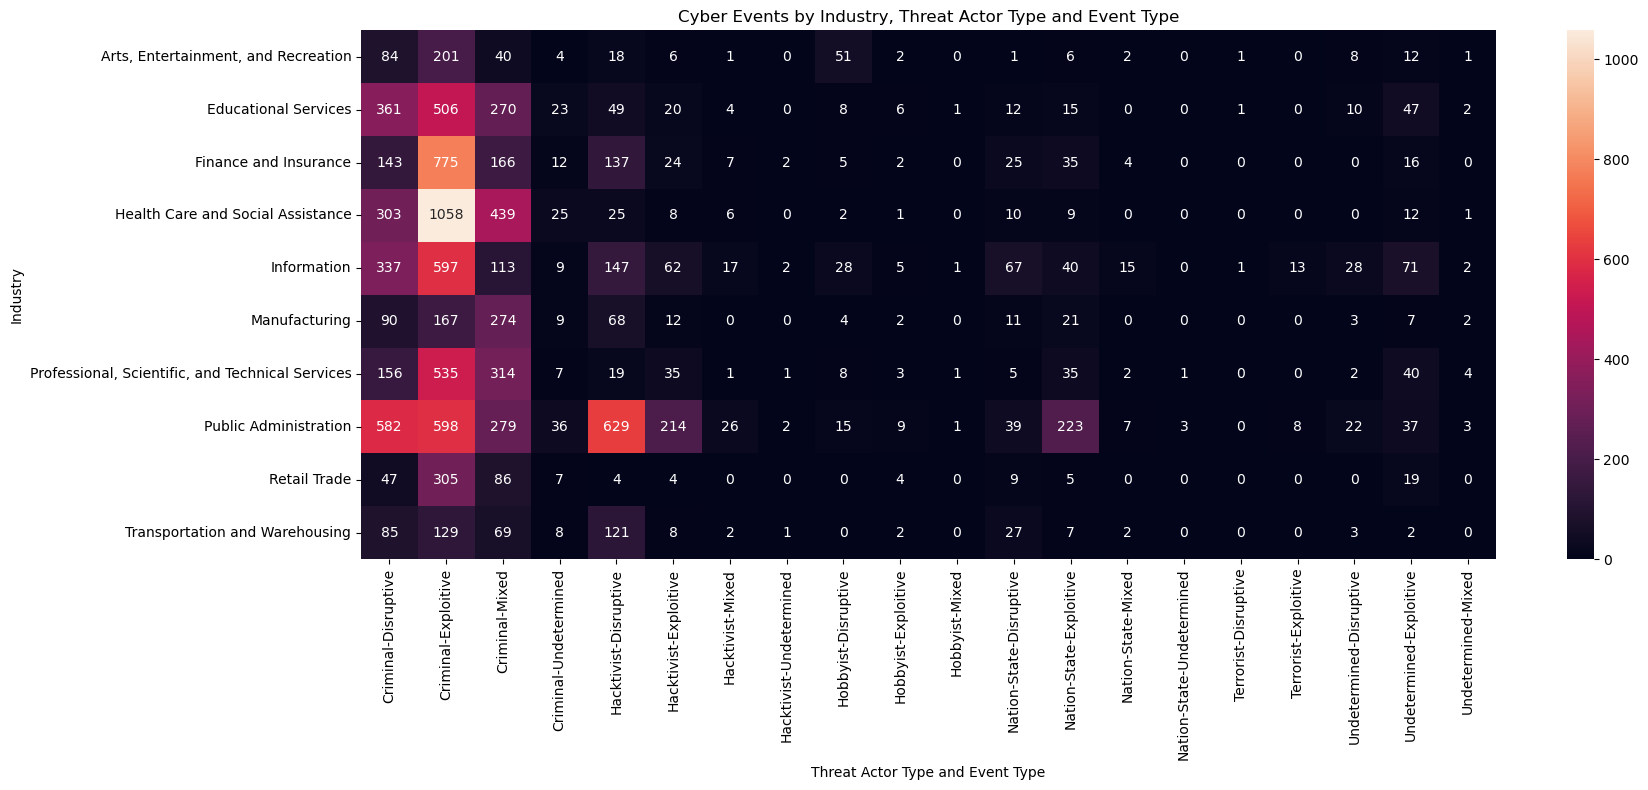

In [82]:
plt.figure(figsize=(18, 8))

sns.heatmap(
    industry_event_actor_pivot,
    annot=True,
    fmt="g"
)

plt.title("Cyber Events by Industry, Threat Actor Type and Event Type")
plt.xlabel("Threat Actor Type and Event Type")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

### Observation
- Criminal actors were the dominant threat-actor group across most major industries.
- Health Care and Social Assistance recorded a particularly high number of Criminal Exploitive events.
- Finance and Insurance also showed strong Criminal Exploitive activity.
- Public Administration had high activity from both Criminal and Hacktivist actors across different event types.
- Information and Educational Services also showed notable activity across multiple actor and event-type combinations.
- Some industries showed different patterns, such as Manufacturing having relatively high Criminal Mixed events.

### Key Insight
- The cybersecurity threat profile varies by industry, with different sectors experiencing different combinations of threat actors and attack types.

In [83]:
motive_event_actor = (
    df.groupby(["motive", "actor_type", "event_type"])
      .size()
      .reset_index(name="event_count")
)

motive_event_actor.head(20)

,motive,actor_type,event_type,event_count
0,Financial,Criminal,Disruptive,1415
1,Financial,Criminal,Exploitive,4027
2,Financial,Criminal,Mixed,2234
3,Financial,Criminal,Undetermined,89
4,Financial,Hacktivist,Disruptive,1
5,Financial,Hacktivist,Exploitive,6
6,Financial,Hacktivist,Mixed,4
7,Financial,Hobbyist,Disruptive,3
8,Financial,Hobbyist,Exploitive,7
9,Financial,Nation-State,Disruptive,62


In [84]:
motive_event_actor_pivot = pd.pivot_table(
    motive_event_actor,
    index="motive",
    columns=["actor_type", "event_type"],
    values="event_count",
    fill_value=0
)

motive_event_actor_pivot

actor_type                    Criminal                                  \
event_type                  Disruptive Exploitive   Mixed Undetermined   
motive                                                                   
Financial                       1415.0     4027.0  2234.0         89.0   
Industrial-Espionage               0.0       39.0     2.0          0.0   
Personal Attack                   21.0       53.0     2.0          0.0   
Political-Espionage                2.0      229.0    10.0          1.0   
Protest                          108.0       28.0     2.0          0.0   
Protest,Financial                  0.0        0.0     0.0          0.0   
Protest;Political-Espionage        0.0        0.0     0.0          0.0   
Sabotage                          92.0       18.0     5.0          0.0   
Undetermined                     813.0     1184.0    78.0         71.0   

actor_type                  Hacktivist                                \
event_type                  Disruptive Exploitive Mixed Undetermined   
motive                                                                 
Financial                          1.0        6.0   4.0          0.0   
Industrial-Espionage               0.0        0.0   0.0          0.0   
Personal Attack                    5.0        4.0   0.0          0.0   
Political-Espionage                0.0        3.0   1.0          0.0   
Protest                         1132.0      308.0  46.0          9.0   
Protest,Financial                  0.0        0.0   1.0          0.0   
Protest;Political-Espionage        0.0        1.0   0.0          0.0   
Sabotage                           6.0        3.0   5.0          0.0   
Undetermined                     240.0      120.0  12.0          0.0   

actor_type                    Hobbyist                  Nation-State  \
event_type                  Disruptive Exploitive Mixed   Disruptive   
motive                                                                 
Financial                          3.0        7.0   0.0         62.0   
Industrial-Espionage               0.0        0.0   0.0          0.0   
Personal Attack                    0.0        1.0   0.0          0.0   
Political-Espionage                0.0        1.0   0.0          5.0   
Protest                            4.0        3.0   0.0          8.0   
Protest,Financial                  0.0        0.0   0.0          0.0   
Protest;Political-Espionage        0.0        0.0   0.0          0.0   
Sabotage                           1.0        0.0   0.0        165.0   
Undetermined                     131.0       34.0   4.0         13.0   

actor_type                                                 Terrorist  \
event_type                  Exploitive Mixed Undetermined Disruptive   
motive                                                                 
Financial                         24.0   5.0          0.0        0.0   
Industrial-Espionage              47.0   0.0          0.0        0.0   
Personal Attack                    1.0   0.0          0.0        0.0   
Political-Espionage              377.0  18.0          2.0        0.0   
Protest                            0.0   0.0          0.0        2.0   
Protest,Financial                  0.0   0.0          0.0        0.0   
Protest;Political-Espionage        0.0   0.0          0.0        0.0   
Sabotage                          18.0  11.0          1.0        1.0   
Undetermined                      31.0   1.0          1.0        2.0   

actor_type                             Undetermined                   
event_type                  Exploitive   Disruptive Exploitive Mixed  
motive                                                                
Financial                          0.0          0.0        4.0   0.0  
Industrial-Espionage               0.0          0.0        4.0   0.0  
Personal Attack                    2.0          1.0        3.0   0.0  
Political-Espionage               19.0          0.0        2.0   0.0  
Protest            

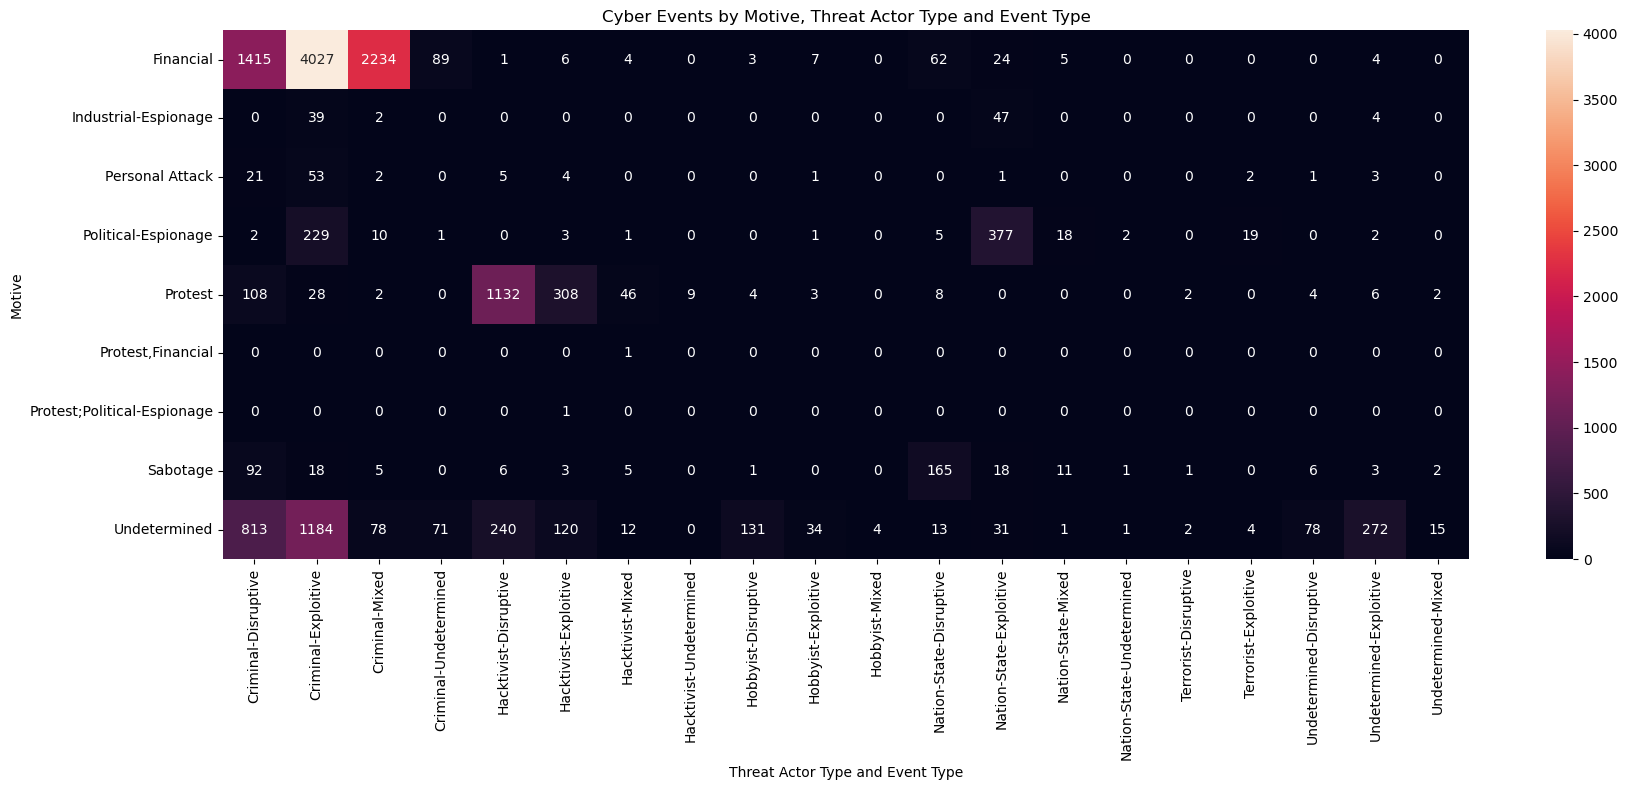

In [85]:
plt.figure(figsize=(18, 8))

sns.heatmap(
    motive_event_actor_pivot,
    annot=True,
    fmt="g"
)

plt.title("Cyber Events by Motive, Threat Actor Type and Event Type")
plt.xlabel("Threat Actor Type and Event Type")
plt.ylabel("Motive")
plt.tight_layout()
plt.show()

### Observation
- Financial motivation was strongly associated with Criminal activity, especially Exploitive and Mixed events.
- Protest-related activity was strongly concentrated among Hacktivists and mainly involved Disruptive events.
- Political-Espionage activity showed a noticeable presence among Nation-State Exploitive events.
- Sabotage showed a stronger association with Nation-State Disruptive activity.
- Undetermined motives were also largely associated with Criminal events.

### Key Insight
- The motivation behind a cyber event is closely linked to both the type of threat actor and the type of activity carried out.

In [86]:
top_industries = df["industry"].value_counts().head(10).index

industry_year_event = (
    df[df["industry"].isin(top_industries)]
    .groupby(["industry", "year", "event_type"])
    .size()
    .reset_index(name="event_count")
)

industry_year_event.head(20)

,industry,year,event_type,event_count
0,"Arts, Entertainment, and Recreation",2014,Disruptive,6
1,"Arts, Entertainment, and Recreation",2014,Exploitive,14
2,"Arts, Entertainment, and Recreation",2014,Mixed,1
3,"Arts, Entertainment, and Recreation",2015,Disruptive,15
4,"Arts, Entertainment, and Recreation",2015,Exploitive,16
5,"Arts, Entertainment, and Recreation",2016,Disruptive,17
6,"Arts, Entertainment, and Recreation",2016,Exploitive,24
7,"Arts, Entertainment, and Recreation",2016,Mixed,1
8,"Arts, Entertainment, and Recreation",2017,Disruptive,19
9,"Arts, Entertainment, and Recreation",2017,Exploitive,21


In [87]:
industry_year_event_pivot = pd.pivot_table(
    industry_year_event,
    index="industry",
    columns=["year", "event_type"],
    values="event_count",
    fill_value=0
)

industry_year_event_pivot

year                                                   2014                   \
event_type                                       Disruptive Exploitive Mixed   
industry                                                                       
Arts, Entertainment, and Recreation                     6.0       14.0   1.0   
Educational Services                                   10.0       31.0   0.0   
Finance and Insurance                                  16.0       22.0   1.0   
Health Care and Social Assistance                       2.0       22.0   0.0   
Information                                            61.0       75.0   5.0   
Manufacturing                                           6.0       10.0   0.0   
Professional, Scientific, and Technical Services       14.0       20.0   0.0   
Public Administration                                 113.0       59.0   4.0   
Retail Trade                                            1.0       32.0   0.0   
Transportation and Warehousing                          4.0        5.0   0.0   

year                                                   2015                   \
event_type                                       Disruptive Exploitive Mixed   
industry                                                                       
Arts, Entertainment, and Recreation                    15.0       16.0   0.0   
Educational Services                                   32.0       48.0   2.0   
Finance and Insurance                                  13.0       31.0   5.0   
Health Care and Social Assistance                       5.0       24.0   1.0   
Information                                            86.0      133.0  10.0   
Manufacturing                                           5.0        7.0   1.0   
Professional, Scientific, and Technical Services        4.0       20.0   0.0   
Public Administration                                 112.0       99.0   5.0   
Retail Trade                                            1.0       41.0   1.0   
Transportation and Warehousing                          8.0       10.0   0.0   

year                                                   2016                   \
event_type                                       Disruptive Exploitive Mixed   
industry                                                                       
Arts, Entertainment, and Recreation                    17.0       24.0   1.0   
Educational Services                                   15.0       36.0   2.0   
Finance and Insurance                                  40.0       54.0   2.0   
Health Care and Social Assistance                       8.0       42.0   2.0   
Information                                            73.0       83.0   4.0   
Manufacturing                                          10.0       12.0   0.0   
Professional, Scientific, and Technical Services        8.0      112.0   3.0   
Public Administration                                 196.0      124.0  11.0   
Retail Trade                                            2.0       30.0   0.0   
Transportation and Warehousing                          6.0        8.0   0.0   

year                                                           ...   2022  \
event_type                                       Undetermined  ...  Mixed   
industry                                                       ...          
Arts, Entertainment, and Recreation                       0.0  ...    6.0   
Educational Services                                      0.0  ...   80.0   
Finance and Insurance                                     0.0  ...   46.0   
Health Care and Social Assistance                         0.0  ...   99.0   
Information                                               0.0  ...   21.0   
Manufacturing                                             0.0  ...  110.0   
Professional, Scientific, and Technical Services          0.0  ...  101.0   
Public Administration                                     0.0  ...   80.0   
Retail Trade                  

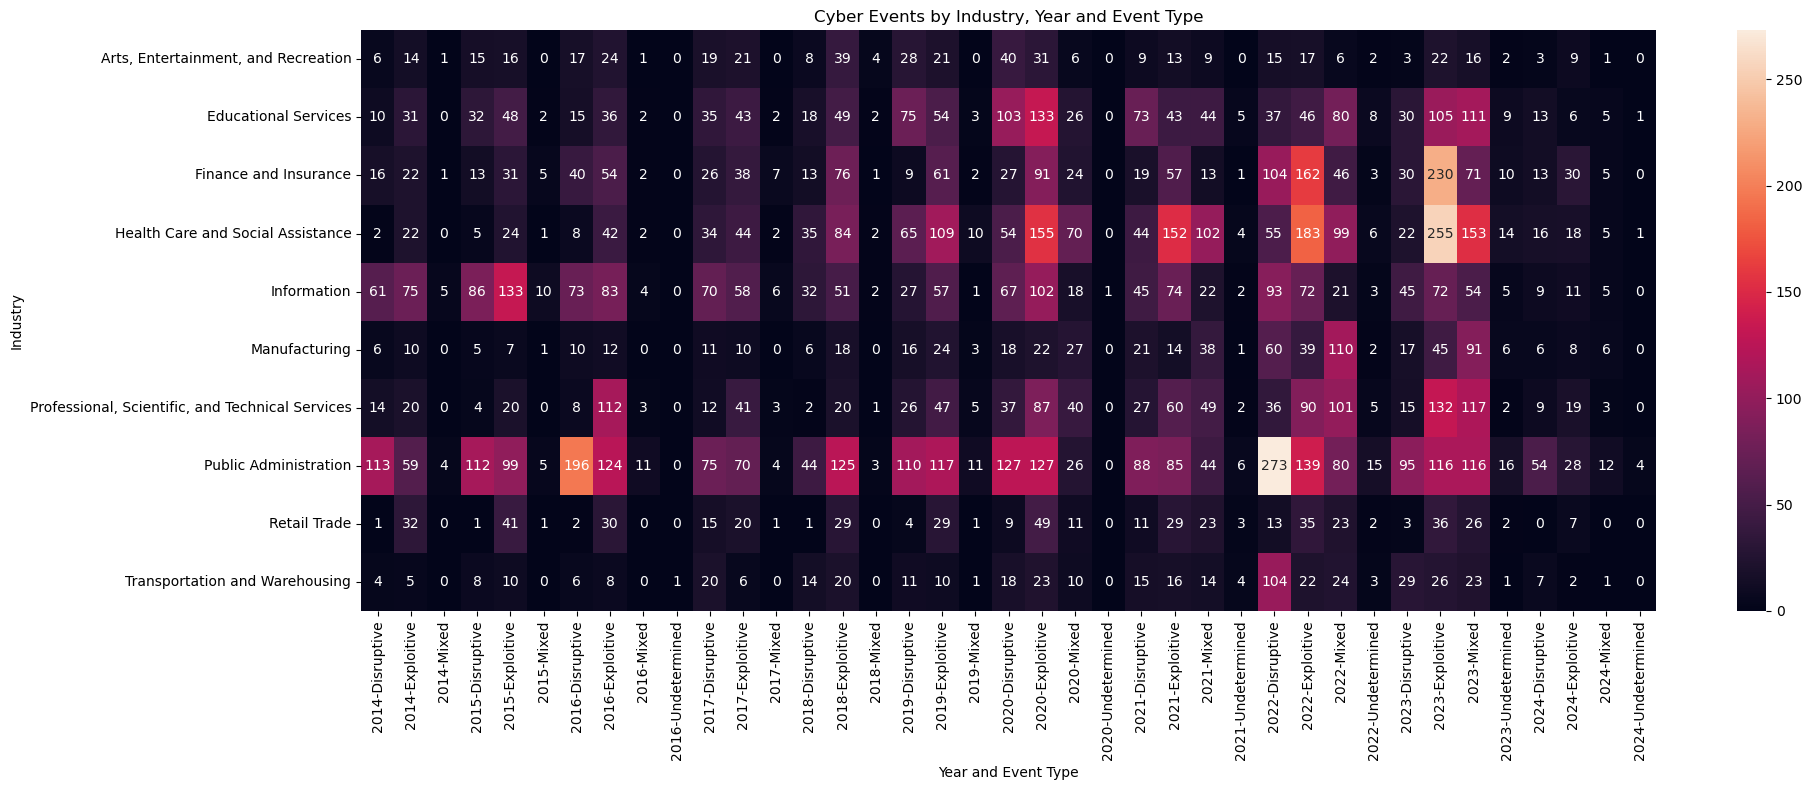

In [88]:
plt.figure(figsize=(20, 8))

sns.heatmap(
    industry_year_event_pivot,
    annot=True,
    fmt="g"
)

plt.title("Cyber Events by Industry, Year and Event Type")
plt.xlabel("Year and Event Type")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

### Observation
- Cyber-event activity varied considerably across industries and years.
- Public Administration, Health Care, Finance, and Information showed higher activity across several years.
- Several industries experienced noticeable increases in Exploitive events during the later years.
- Public Administration showed consistently high activity across multiple years and event types.
- The high activity observed during 2020–2023 appears across several major industries.
- The lower values in 2024 should be interpreted cautiously because the available data may not represent a complete year.

### Key Insight
- Cybersecurity activity changes across both industries and time, showing that organizations need continuous monitoring of sector-specific attack trends.

## Multivariate Analysis – Key Findings

- Criminal actors dominate cyber-event activity across most industries and years.
- Exploitive events are strongly associated with Criminal actors and Financial motives.
- Hacktivist activity is more strongly associated with Disruptive events and Protest motives.
- Nation-State activity shows notable links with Political-Espionage and Sabotage.
- Cyber-event patterns vary significantly across industries and over time.
- Activity was particularly high across several sectors during 2020–2023.
- The 2024 decline should be interpreted cautiously due to potentially incomplete coverage.

### Overall Insight
Cyber threats are not uniform. The type of threat actor, their motive, the attack type, the affected industry, and the year together provide a much clearer picture of the cybersecurity landscape.

In [89]:
year_summary = pd.pivot_table(
    df,
    index="year",
    columns="event_type",
    values="slug",
    aggfunc="count",
    fill_value=0
)

year_summary

event_type,Disruptive,Exploitive,Mixed,Undetermined
year,,,,
2014,262,358,13,0
2015,316,509,32,0
2016,445,628,30,1
2017,360,422,28,0
2018,205,599,20,0
2019,414,614,39,0
2020,561,901,283,2
2021,397,597,405,32
2022,892,940,671,58


In [90]:
year_summary["Total Events"] = year_summary.sum(axis=1)

year_summary

event_type,Disruptive,Exploitive,Mixed,Undetermined,Total Events
year,,,,,
2014,262,358,13,0,633
2015,316,509,32,0,857
2016,445,628,30,1,1104
2017,360,422,28,0,810
2018,205,599,20,0,824
2019,414,614,39,0,1067
2020,561,901,283,2,1747
2021,397,597,405,32,1431
2022,892,940,671,58,2561


### Why this pivot table?

- This table summarizes cyber-event activity by year and event type.
- It makes it easy to compare yearly changes in Disruptive, Exploitive, Mixed, and Undetermined events.
- A total column helps identify the years with the highest overall recorded activity.
### Observation
- Cyber-event activity generally increased over the years, with the highest total recorded activity in 2022 (2,561 events).
- Exploitive events remained the largest event type in most years and reached 1,161 events in 2023.
- Mixed events increased sharply from 283 in 2020 to 887 in 2023.
- Disruptive events peaked at 892 in 2022.
- 2023 recorded slightly fewer total events than 2022, but Exploitive and Mixed events were both higher.
- The sharp drop in 2024 should be interpreted cautiously because the available data may not represent a complete year.

### Key Insight
Cyber-event patterns changed over time, with Exploitive activity consistently prominent and Mixed events becoming increasingly significant in the later years.

In [91]:
industry_event_summary = pd.pivot_table(
    df,
    index="industry",
    columns="event_type",
    values="slug",
    aggfunc="count",
    fill_value=0
)

industry_event_summary

event_type,Disruptive,Exploitive,Mixed,Undetermined
industry,,,,
Accommodation and Food Services,38,219,43,4
Administrative and Support and Waste Management and Remediation Services,44,94,35,3
"Agriculture, Forestry, Fishing and Hunting",11,5,9,0
"Arts, Entertainment, and Recreation",163,227,44,4
Construction,10,12,27,1
Educational Services,441,594,277,23
Finance and Insurance,310,852,177,14
Health Care and Social Assistance,340,1088,446,25
Information,608,788,148,11


In [92]:
industry_event_summary["Total Events"] = industry_event_summary.sum(axis=1)

industry_event_summary = industry_event_summary.sort_values(
    "Total Events",
    ascending=False
)

industry_event_summary

event_type,Disruptive,Exploitive,Mixed,Undetermined,Total Events
industry,,,,,
Public Administration,1287,1089,316,41,2733
Health Care and Social Assistance,340,1088,446,25,1899
Information,608,788,148,11,1555
Finance and Insurance,310,852,177,14,1353
Educational Services,441,594,277,23,1335
"Professional, Scientific, and Technical Services",190,648,322,9,1169
Manufacturing,176,209,276,9,670
Retail Trade,60,337,86,7,490
Transportation and Warehousing,236,148,73,9,466


In [93]:
industry_event_summary.head(10)

event_type,Disruptive,Exploitive,Mixed,Undetermined,Total Events
industry,,,,,
Public Administration,1287,1089,316,41,2733
Health Care and Social Assistance,340,1088,446,25,1899
Information,608,788,148,11,1555
Finance and Insurance,310,852,177,14,1353
Educational Services,441,594,277,23,1335
"Professional, Scientific, and Technical Services",190,648,322,9,1169
Manufacturing,176,209,276,9,670
Retail Trade,60,337,86,7,490
Transportation and Warehousing,236,148,73,9,466


### Observation
- Public Administration recorded the highest overall cyber activity with 2,733 events.
- Health Care and Social Assistance followed with 1,899 events, with Exploitive events being the largest category.
- Information, Finance and Insurance, and Educational Services were also among the most affected industries.
- Public Administration had the highest number of Disruptive events (1,287).
- Health Care and Social Assistance had 1,088 Exploitive events, while Finance and Insurance recorded 852.
- Manufacturing showed a relatively higher number of Mixed events compared with its Disruptive and Exploitive events.

### Key Insight
Cyber-event exposure varies considerably across industries, with Public Administration and Health Care showing particularly high levels of recorded activity and different attack-type patterns.

In [94]:
actor_motive_summary = pd.pivot_table(
    df,
    index="actor_type",
    columns="motive",
    values="slug",
    aggfunc="count",
    fill_value=0
)

actor_motive_summary

motive,Financial,Industrial-Espionage,Personal Attack,Political-Espionage,Protest,"Protest,Financial",Protest;Political-Espionage,Sabotage,Undetermined
actor_type,,,,,,,,,
Criminal,7765,41,76,242,138,0,0,115,2146
Hacktivist,11,0,9,4,1495,1,1,14,372
Hobbyist,10,0,1,1,7,0,0,1,169
Nation-State,91,47,1,402,8,0,0,195,46
Terrorist,0,0,2,19,2,0,0,1,6
Undetermined,4,4,4,2,12,0,0,11,365


In [95]:
actor_motive_summary["Total Events"] = actor_motive_summary.sum(axis=1)

actor_motive_summary = actor_motive_summary.sort_values(
    "Total Events",
    ascending=False
)

actor_motive_summary

motive,Financial,Industrial-Espionage,Personal Attack,Political-Espionage,Protest,"Protest,Financial",Protest;Political-Espionage,Sabotage,Undetermined,Total Events
actor_type,,,,,,,,,,
Criminal,7765,41,76,242,138,0,0,115,2146,10523
Hacktivist,11,0,9,4,1495,1,1,14,372,1907
Nation-State,91,47,1,402,8,0,0,195,46,790
Undetermined,4,4,4,2,12,0,0,11,365,402
Hobbyist,10,0,1,1,7,0,0,1,169,189
Terrorist,0,0,2,19,2,0,0,1,6,30


In [96]:
actor_motive_summary

motive,Financial,Industrial-Espionage,Personal Attack,Political-Espionage,Protest,"Protest,Financial",Protest;Political-Espionage,Sabotage,Undetermined,Total Events
actor_type,,,,,,,,,,
Criminal,7765,41,76,242,138,0,0,115,2146,10523
Hacktivist,11,0,9,4,1495,1,1,14,372,1907
Nation-State,91,47,1,402,8,0,0,195,46,790
Undetermined,4,4,4,2,12,0,0,11,365,402
Hobbyist,10,0,1,1,7,0,0,1,169,189
Terrorist,0,0,2,19,2,0,0,1,6,30


### Why this pivot table?

- This table compares threat actors with their recorded motives.
- It helps identify what motivates different types of attackers.
- The total column shows the overall activity associated with each threat-actor group.
- This provides a clearer view of attacker behavior than looking at actor type and motive separately.
  ### Observation
- Criminal actors recorded the highest number of events, with 10,523 incidents.
- Financial motivation was strongly associated with Criminal actors, with 7,765 events.
- Hacktivists were strongly associated with Protest motives, with 1,495 events.
- Nation-State actors showed a strong association with Political-Espionage (402) and Sabotage (195).
- Undetermined motives were relatively common among Criminal and Hacktivist events.
- Terrorist activity was very limited in the dataset, with only 30 recorded events.

### Key Insight
Different threat-actor groups show distinct motivations: Criminal activity is mainly financially driven, Hacktivist activity is largely protest-driven, while Nation-State activity is more associated with political-espionage and sabotage.

In [97]:
top_industry_summary = (
    df["industry"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_industry_summary.columns = ["Industry", "Total Events"]

top_industry_summary

,Industry,Total Events
0,Public Administration,2733
1,Health Care and Social Assistance,1899
2,Information,1555
3,Finance and Insurance,1353
4,Educational Services,1335
5,"Professional, Scientific, and Technical Services",1169
6,Manufacturing,670
7,Retail Trade,490
8,Transportation and Warehousing,466
9,"Arts, Entertainment, and Recreation",438


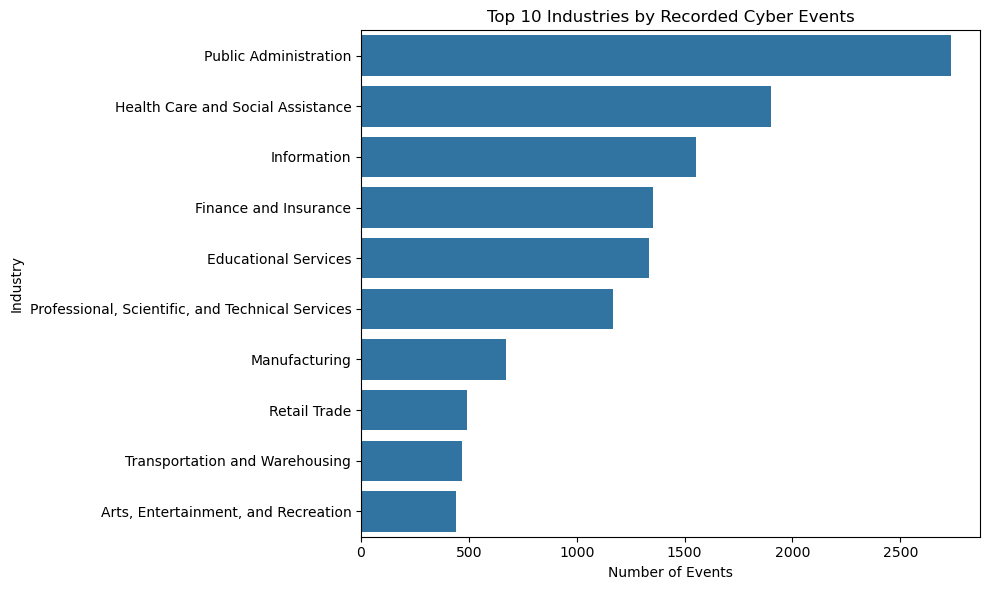

In [98]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_industry_summary,
    x="Total Events",
    y="Industry"
)

plt.title("Top 10 Industries by Recorded Cyber Events")
plt.xlabel("Number of Events")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

### Why this plot?

- A horizontal bar chart is used to rank the top industries by total recorded cyber events.
- It makes differences between industries easy to compare.
- Focusing on the top 10 keeps the visualization clear and readable.
### Observation
- Public Administration had the highest number of recorded cyber events with 2,733 incidents.
- Health Care and Social Assistance ranked second with 1,899 events.
- Information, Finance and Insurance, and Educational Services also recorded high levels of cyber activity.
- The top six industries each recorded more than 1,000 events.
- Manufacturing, Retail Trade, Transportation and Warehousing, and Arts, Entertainment, and Recreation had lower activity compared with the leading sectors.

### Key Insight
Cyber-event activity is concentrated in a small group of major industries, particularly Public Administration, Health Care, Information, Finance, and Education.

## 7. Visual & Non-Visual Insights – Key Findings

### Major Findings

- **Exploitive events** were the most common event type, accounting for nearly half of all recorded events.
- **Criminal actors** dominated the dataset, with 10,523 recorded events.
- **Financial motivation** was strongly associated with Criminal activity, with 7,765 events.
- **Hacktivist activity** was strongly associated with Protest motives, with 1,495 events.
- **Nation-State activity** showed stronger associations with Political-Espionage and Sabotage.
- **Public Administration** recorded the highest overall cyber activity with 2,733 events, followed by Health Care and Social Assistance with 1,899.
- **2022** recorded the highest total number of events with 2,561, while **2023** had the highest number of Exploitive and Mixed events.
- Cyber-event patterns varied across **years, industries, threat actors, motives, and event types**.

### Overall Insight

The analysis shows that cyber threats are highly varied and depend on the attacker, motivation, attack type, affected industry, and time period. This highlights the importance of continuous monitoring and industry-specific cybersecurity strategies.

## 8.1 Key Takeaways

- Exploitive events were the most frequently recorded cyber-event type.
- Criminal actors accounted for the majority of recorded events.
- Financial motivation was strongly associated with Criminal activity.
- Hacktivist activity was mainly associated with Protest motives and Disruptive events.
- Nation-State activity showed stronger associations with Political-Espionage and Sabotage.
- Public Administration recorded the highest number of cyber events, followed by Health Care and Social Assistance.
- Cyber-event activity was particularly high during 2020–2023, with 2022 recording the highest total.
- Cyber-event patterns varied across industries, threat actors, motives, event types, and time.

## 8.2 Cybersecurity Insights & Recommendations

Based on the analysis, the following recommendations can be considered:

- **Strengthen protection against exploitation:** Organizations should prioritize patch management, vulnerability assessment, and secure configuration of application servers and end hosts.
- **Focus on financially motivated threats:** Organizations should strengthen access controls, authentication, monitoring, and fraud detection to reduce financially motivated attacks.
- **Monitor sector-specific risks:** Industries such as Public Administration, Health Care, Finance, and Information should maintain stronger threat monitoring due to their high level of recorded activity.
- **Track threat-actor behavior:** Security teams should monitor changes in Criminal, Hacktivist, and Nation-State activity to understand evolving attack patterns.
- **Use historical trends for preparedness:** Yearly and industry-level trends can support cybersecurity planning, resource allocation, and risk prioritization.
- **Improve incident intelligence:** Recording attacker type, motive, event type, affected sector, and timeline consistently can improve future threat analysis.

## 8.3 Overall Conclusion

This project analyzed the UMD Cyber Events Database to understand patterns in cyber incidents across different years, industries, threat actors, motives, and event types.

The analysis showed that Criminal actors and Exploitive events dominated the recorded cyber-event landscape, while different threat actors demonstrated distinct motivations and activity patterns. Public Administration, Health Care, Information, Finance, and Educational Services were among the most affected industries.

The combination of univariate, bivariate, multivariate, and pivot-table analysis provided a deeper understanding of how cyber threats vary across time and sectors.

Overall, the project demonstrates how exploratory data analysis can be used to transform raw cybersecurity event data into meaningful insights that can support threat monitoring, risk assessment, and cybersecurity decision-making.

## 8.4 Project Learnings

Through this project, I learned how to:

- Load and explore a real-world cybersecurity dataset using Python and Pandas.
- Identify and handle missing values without unnecessarily removing useful records.
- Check duplicate records and unique identifiers.
- Evaluate whether outlier treatment is statistically appropriate.
- Identify class/category imbalance in real-world data.
- Perform univariate, bivariate, and multivariate analysis.
- Select appropriate visualizations based on the type of data and analytical question.
- Use pivot tables to generate numerical summaries and comparisons.
- Interpret cybersecurity patterns from data rather than relying only on visualizations.
- Convert analytical findings into practical cybersecurity recommendations.

## 8.5 Project Limitations

- The dataset represents recorded cyber events and may not capture every cyber incident that occurred.
- The number of recorded events can be influenced by reporting and data availability.
- Some event motivations and actor identities are classified as Undetermined.
- The 2024 data contains substantially fewer records and should therefore be interpreted cautiously.
- Some categorical values contain combined or inconsistent-looking labels, particularly within event subtypes.
- The analysis identifies patterns and associations but does not establish causal relationships.

## 8.6 Future Scope

The project can be extended by:

- Building an interactive cybersecurity dashboard using Power BI or Tableau.
- Adding severity and impact analysis where additional severity-related data is available.
- Performing time-series forecasting of cyber-event activity.
- Applying clustering techniques to identify groups of similar cyber incidents.
- Developing automated threat-pattern monitoring using Python.
- Integrating additional cybersecurity datasets such as data breaches, vulnerabilities, or threat intelligence feeds.
- Building a cybersecurity analytics pipeline for continuous monitoring and reporting.

## Final Takeaway

> **Cybersecurity data becomes more valuable when we move beyond counting incidents and understand who is attacking, why they are attacking, what methods are being used, and which industries are most affected.**

This project demonstrates how Python-based exploratory data analysis can help uncover these patterns and translate them into meaningful cybersecurity insights.